# **Connecticut Housing Affordability Analysis & Forecasting**

Analyzing the widening gap between housing prices and occupational income using historical data, inflation-adjusted metrics, and XGBoost forecasting.



---



## **Group Members:**






### **Kayla Tucker**

Web Portfolio: https://github.com/kaylajtucker/Portfolio

### **Derrick Eberlin**

Web Portfolio: https://derrickeberlein.dev

### **Reagan McCoy**

Web Portfolio: https://rmcco008.github.io/


---


---
## **Table of Contents**



1.   Raw Data Sources
2.   Raw Data Source Records
3.  End Goal
4. Important Dates
5. Meeting Times
6. Project Plan
7. Progess Check I
8. Progess Check II
9. Summary
10. Conclusion
11. Future Work
12. References
13. Youtube Link



## **Abstract**

## This study seeks to analyze a national dataset on housing income to investigate whether homeownership in the Connecticut has become increasingly unaffordable. This research is important, as homeownership is one of the most sought-after investments amongst adults in America. We aim to explain disparities between average house prices and average salaries across Connecticut from 2006-2023, and highlight how rising housing costs may be outpacing income growth. We also aim to investigate occupational differences in affordability and identify which occupations face the harshest homeownership financial barriers. This analysis can offer valuable evidence for policymakers to address affordability challenges and encourage them to work on strategies to make homeownership more accessible.

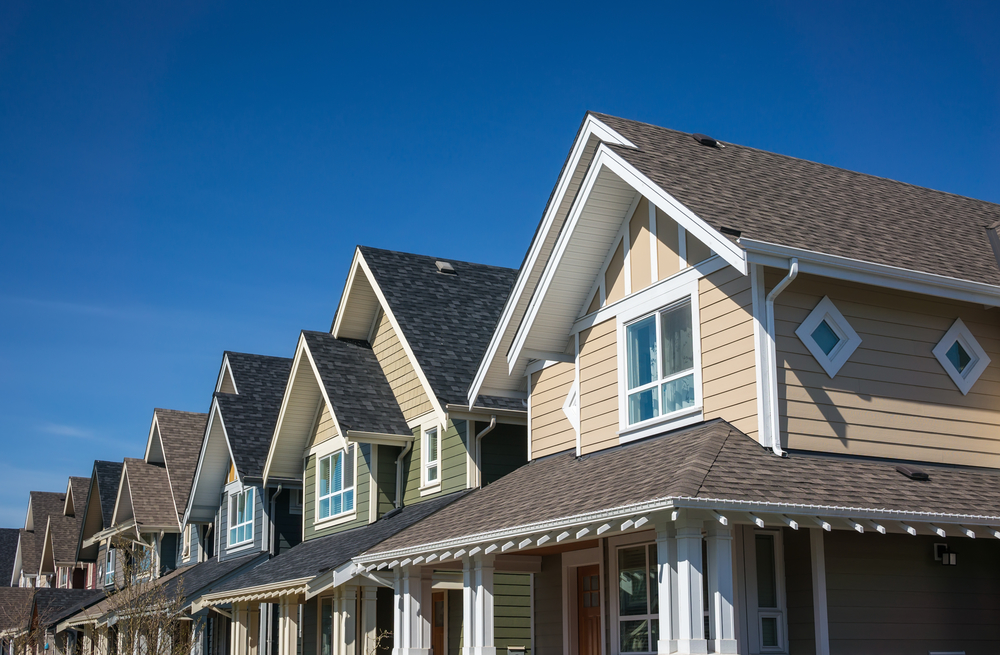

---
##**1. Raw Data Sources**




*   [Housing Prices](https://catalog.data.gov/dataset/real-estate-sales-2001-2018) (Primary)
     *  **Dataset Description:** *The sale price for every house in Connecticut from 2001 to 2023, includes the assessed value of the house, the actual sale price, the year it was sold, the sales ratio, the street address for each house, and the town for each house.*
*   [Average Income](https://www.bls.gov/oes/tables.htm) (Secondary)
    *  **Dataset Description:** The annual income for occupations in Connecticut from 1997-2024. Each year is a separate dataset, so this data consists of 27 individual datasets.


---



---
## **2. Raw Data Source Records**

Housing Prices:

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

housing = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/CT_HouseSales.csv")

housing.head(5)

Mounted at /content/gdrive


/tmp/ipython-input-1543088632.py:5: DtypeWarning: Columns (7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  housing = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/CT_HouseSales.csv")


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,133000.0,248400.0,0.5354,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014)
1,2020225,2020,05/26/2021,Ansonia,152 JACKSON ST,110500.0,239900.0,0.4606,Residential,Three Family,NaN,NaN,NaN,NaN
2,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.463,Commercial,NaN,NaN,NaN,NaN,NaN
3,2020090,2020,12/14/2020,Ansonia,57 PLATT ST,127400.0,202500.0,0.6291,Residential,Two Family,NaN,NaN,NaN,NaN
4,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,179990.0,362500.0,0.4965,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988)


Average Income:

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

df = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/Income_2023.csv")

df.head(5)

Mounted at /content/gdrive


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,19.88,30.09,46.18,"22,620","29,580","41,350","62,580","96,050",NaN,NaN
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,47.95,67.22,95.44,"50,710","73,180","99,740","139,810","198,520",NaN,NaN
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,79.48,102.01,#,"65,700","123,960","165,320","212,180",#,NaN,NaN
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,49.67,78.25,112.54,"48,080","72,260","103,320","162,760","234,080",NaN,NaN
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1031,Legislators,...,*,*,*,"18,320","19,670","24,470","45,050","55,070",True,NaN


In [ ]:
#seeing what columns the df has
df.columns

Index(['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE',
       'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP',
       'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT',
       'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN',
       'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75',
       'A_PCT90', 'ANNUAL', 'HOURLY'],
      dtype='object')


---


## **3. End Goal**


*   Using the Housing Prices in Connecticut from 2006-2023 and comparing that to the average occupational salary in Connecticut during that time span to see if houses have become an unaffordable investment in modern times. To do this we will find data such as the percentage difference between median house values and occupational income for each year. Finding information like the percentage difference between the average house cost to the average income for that state of Connecticut. Finally, we track The percentage difference between the median income and the average house for each year to track trends to see if the average difference increases or decreases over time.
    * We will create graphs to showcase and track this data to better illustrate the changes in income to housing prices over the last 20 years.

---

---
## **4. Important Dates**



**9/14/2025 -** Abstract

**10/12/2025 -** Progress Check 1

**11/9/2025 -** Progress Check 2

**12/5/2025 -** Final Report and Presentation/Demo



---


---
## **5. Meeting Times**



Tuesday: 2:30 PM

(Optional): Thursday/Friday 2:30 PM


---


---
## **6. Project Plan**



1.   Prepping Data

*   Select the topic that interests the group (**9/01/2025**)

2.   Create Google Colab Notebook (**9/07/2025**)
* Begin abstract and Project Planning.
  * Find raw/unprocessed datasets that relate to the topic
  * Use the datasets found to address a question
  * Make sure the datasets can find a possible solution to the goal
* Create a Project Plan
  * *Dates may be subject to changes*
* Create End Goal

3. Analyze Data (**10/12/2025**)
* Clean raw data sets found for the topic
  *   Remove duplicates
  *   Standardize data format
  *   Filter unwanted outliers
  *   Handle missing data
* Create charts and diagrams to fit project description
* Use python (or other coding languages) to achieve results
* Submit Progress Check 1 (**10/12/2025**)

4. Visualize Data (**10/12/2025 - 11/20/2025**)

* Comparative analysis of housing prices and income percentage differences.
* Create visualizers displaying the differences in housing prices to occupational income over the last twenty years.
* Train machine learning models to predict percentage differences in upcoming years.
* Create visualizers displaying to predicted differences.
* Repeat process for specific occupations (Optional)
* Submit Progress Check 2 (**11/09/2025**)


5. Create and Submit Video Presentation (**11/20/2025 - 12/05/2025**)
6. Touch-up Final Report (**11/20/2025 - 12/05/2025**)
7. Group Evaluations (**12/05/22025**)


---



---
## **7. Progess Check I**




### **Outline**

#### **Target Audience**
* The target audience for this analysis is middle-class homeowners in Connecticut and those with a middle-class income looking to purchase a house in Connecticut. This analysis should help show those who own a home or are looking for one, the trends in the rates of housing prices compared to middle class income rates in recent years. This could help in deducing if the ability to purchase a home has become increasingly unaffordable in the last 20 years.

#### **Tools/Technologies**
* Language: Python
* Libraries: Numpy, Pandas, Scikit-learn, Matplotlib

#### **Overall Design**
* Cleans all of Connecticut's housing data from 2006-2023 and removes any significant outliers. The houses considered are mainly in the range from greater than 50,000 to less than 800,000 dollars spanning the years 2006-2023. **This cleaning process is demonstrated in the "Cleaning Housing Data" portion of this Abstract.**
* Cleans all of Connecticut's income data from 18 different datasets (1 dataset for each year). Saves the 10th , 25th, 50th, 75th, and 90th percentiles, along with the average income for all occupations in the state of Connecticut for each year and saves them all to one dataframe. **This cleaning process is demonstrated in the "Cleaning Income Data" portion of this Abstract.**
* By using the housing data from each year with the income data from that same year, an analysis will be performed to see if the increase in housing prices is proportional to the increase in income rates. Ultimately, through various calculations and visualizations, we will be able to deduce if housing has become unaffordable for the Connecticut middle class in  the last 20 years.

#### **Current Status**
* The housing and income datasets have been fully cleaned, organized, and prepared for analysis. Visualizations were created to highlight initial trends within each dataset, including yearly fluctuations in home sale prices and income levels. Early findings indicate noticeable variations across the years, with certain periods reflecting clear economic impacts such as rapid housing growth and later declines. These visuals provide a strong foundation for identifying patterns and disparities between income and housing trends in future stages of analysis. **Visualizations of the current cleaned datasets are available in the "Visualizing Data" portion of this Abstract.**

#### **Left To Do**
* Conduct a comparative analysis of the cleaned income and housing datasets to identify disparities and percentage differences between the two, as well as their respective inflation and growth rates from 2006 to 2023.

* Apply statistical and visual analysis techniques—such as correlation and trendline modeling—to evaluate the relationship between income growth and housing price increases across the study period.

* Examine whether the rate of housing price growth in Connecticut has consistently outpaced income growth, thereby contributing to reduced housing affordability for the middle class.

* Generate visualizations and summary tables that clearly depict yearly disparities, percentage changes, and inflation-adjusted comparisons.

* Interpret the results to draw conclusions regarding long-term affordability trends and discuss potential socioeconomic implications.

* Prepare a concise summary section to synthesize key findings and highlight areas for future research or policy consideration.

### **Cleaning Housing Data**

In [ ]:
# Remove Columns from Dataset that don't affect the goal of the project.
cleaned_df = housing[housing['Property Type'] != 'Commercial']
cleaned_df = cleaned_df.drop(columns=['OPM remarks', 'Location', 'Address', 'Town', 'Non Use Code', 'Assessor Remarks'])

# Print Head of new dataframe
cleaned_df.head(5)

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,2020177,2020,04/14/2021,133000.0,248400.0,0.5354,Residential,Single Family
1,2020225,2020,05/26/2021,110500.0,239900.0,0.4606,Residential,Three Family
3,2020090,2020,12/14/2020,127400.0,202500.0,0.6291,Residential,Two Family
4,210288,2021,06/20/2022,179990.0,362500.0,0.4965,Residential,Condo
5,200500,2020,09/07/2021,217640.0,400000.0,0.5441,Residential,Single Family


The above code cell represents the first step in cleaning the housing dataset. Since the focus of this project is on tracking changes in housing affordability in Connecticut, any properties purchased for **`Commercial`** use are excluded, as they are not relevant to the project’s goals. In addition, several columns—such as **`OPM remarks`**, **`Location`**, **`Address`**, **`Town`**, **`Non Use Code`**, and **`Assessor Remarks`**—are removed because they do not contribute to the project’s analysis and would only introduce unnecessary noise into the dataset.

In [ ]:
# Check for any NaN values
print("NaN For each Columns")
display(cleaned_df.isnull().sum())

NaN For each Columns


,0
Serial Number,0
List Year,0
Date Recorded,2
Assessed Value,0
Sale Amount,0
Sales Ratio,0
Property Type,382446
Residential Type,395090


The purpose of the above cell is to check for any **`NaN`** values in the dataset to determine whether they should be addressed through removal, sampling, or another cleaning method, depending on both the number of affected cells and the specific column in which the **`NaN`** values occur.

In [ ]:
# Remove any rows that have NaN as the Property Type
cleaned_df = cleaned_df.dropna(subset=['Property Type'])

# Check for NaN values
print("NaN For each Columns")
display(cleaned_df.isnull().sum())

NaN For each Columns


,0
Serial Number,0
List Year,0
Date Recorded,0
Assessed Value,0
Sale Amount,0
Sales Ratio,0
Property Type,0
Residential Type,12644


The purpose of the above cell is to enforce data integrity by removing over 300,000 records with missing values in the **`Property Type`** field. Given the impracticality of imputing or otherwise addressing such a substantial proportion of missing data, these records were omitted. The cell then evaluates the dataset for remaining missing values across all columns to inform subsequent cleaning strategies, such as **`imputation`**, **`removal`**, or **`other targeted methods`**.

### **Cleaning via K-Nearest Neighbors**




Use K-Nearest Neighbors (k-NN) imputation to clean the 12k remaining data values in the Residential Type Column.

In [ ]:
# Select relevant columns for k-NN imputation
imputation_cols = ['Assessed Value', 'Sale Amount', 'Sales Ratio', 'List Year', 'Residential Type']
imputation_df = cleaned_df[imputation_cols].copy()

# Display the head of the new DataFrame
display(imputation_df.head())

,Assessed Value,Sale Amount,Sales Ratio,List Year,Residential Type
0,133000.0,248400.0,0.5354,2020,Single Family
1,110500.0,239900.0,0.4606,2020,Three Family
3,127400.0,202500.0,0.6291,2020,Two Family
4,179990.0,362500.0,0.4965,2021,Condo
5,217640.0,400000.0,0.5441,2020,Single Family


The above cell subsets the dataset to the variables required for k-NN imputation—`Assessed Value`, `Sale Amount`, `Sales Ratio`, `List Year`, and the target `Residential Type`—and creates a copy to avoid modifying the original frame in place. It then displays the first few rows as a quick sanity check to verify column selection and data types before running the imputation.

In [ ]:
# Convert the 'Residential Type' categorical column into a one-hot encoded format.
# This is necessary because k-NN algorithms work with numerical data.
# dummy_na=False ensures that NaN values do not create a separate category.
imputation_df = pd.get_dummies(imputation_df, columns=['Residential Type'], dummy_na=False)
display(imputation_df.head())

,Assessed Value,Sale Amount,Sales Ratio,List Year,Residential Type_Condo,Residential Type_Four Family,Residential Type_Single Family,Residential Type_Three Family,Residential Type_Two Family
0,133000.0,248400.0,0.5354,2020,False,False,True,False,False
1,110500.0,239900.0,0.4606,2020,False,False,False,True,False
3,127400.0,202500.0,0.6291,2020,False,False,False,False,True
4,179990.0,362500.0,0.4965,2021,True,False,False,False,False
5,217640.0,400000.0,0.5441,2020,False,False,True,False,False


The above cell converts the categorical `Residential Type` variable into numerical form via one-hot encoding so it can be used by k-NN, which requires numeric inputs. Using `dummy_na=False` prevents creation of a separate “NaN” category (rows with missing `Residential Type` receive zeros across all dummy columns). The head is displayed to verify the transformation before imputation.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Separate data with and without missing 'Residential Type'
missing_residential_mask = cleaned_df['Residential Type'].isnull()
data_with_residential = cleaned_df[~missing_residential_mask].copy()
data_without_residential = cleaned_df[missing_residential_mask].copy()

# Select features for KNN (excluding the original 'Residential Type' column and Property Type)
features_for_knn = data_with_residential[['Assessed Value', 'Sale Amount', 'Sales Ratio', 'List Year']].copy()
features_without_residential = data_without_residential[['Assessed Value', 'Sale Amount', 'Sales Ratio', 'List Year']].copy()

# No need to one-hot encode Property Type anymore as it's removed from features

# Separate target variable for training data (one-hot encoded 'Residential Type')
residential_encoder = pd.get_dummies(data_with_residential['Residential Type'], prefix='Residential Type', dummy_na=False)
train_target = residential_encoder

# Scale numerical features
# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
train_data = scaler.fit_transform(features_for_knn)
test_data = scaler.transform(features_without_residential)

# Convert back to DataFrames to keep column names for clarity (optional but helpful)
train_data = pd.DataFrame(train_data, columns=features_for_knn.columns, index=data_with_residential.index)
test_data = pd.DataFrame(test_data, columns=features_without_residential.columns, index=data_without_residential.index)

print("Scaled Training Data Head:")
display(train_data.head())
print("\nScaled Test Data Head:")
display(test_data.head())
print("\nTraining Target Head:")
display(train_target.head())

Scaled Training Data Head:


,Assessed Value,Sale Amount,Sales Ratio,List Year
0,0.000151,0.000779,4.365552e-07,0.823529
1,0.000125,0.000753,3.755647e-07,0.823529
3,0.000145,0.000635,5.129564e-07,0.823529
4,0.000204,0.001137,4.048368e-07,0.882353
5,0.000247,0.001255,4.436490e-07,0.823529



Scaled Test Data Head:


,Assessed Value,Sale Amount,Sales Ratio,List Year
24,0.000125,0.000157,1.803787e-06,0.882353
26,0.000054,0.000314,3.875508e-07,0.823529
27,0.000054,0.000141,8.630812e-07,0.823529
29,0.000010,0.000121,1.778347e-07,0.823529
39,0.000051,0.000313,3.673293e-07,0.882353



Training Target Head:


,Residential Type_Condo,Residential Type_Four Family,Residential Type_Single Family,Residential Type_Three Family,Residential Type_Two Family
0,False,False,True,False,False
1,False,False,False,True,False
3,False,False,False,False,True
4,True,False,False,False,False
5,False,False,True,False,False


The above cell prepares the dataset for k-NN classification of `Residential Type` by  


1.   Splitting the data into rows with and without `Residential Type`
2.   Selecting the numeric predictor features (`Assessed Value`, `Sale Amount`, `Sales Ratio`, `List Year`)
3. One-hot encoding the known `Residential Type` values to create the training target
4. Scaling features to the range **0,1** with `MinMaxScaler`, fitting on the training subset and applying the same transform to the missing subset to ensure meaningful distance calculations

Finally, the scaled arrays are converted back into DataFrames for clarity, and the heads of the training data, test data, and training target are displayed for verification prior to running k-NN.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the k-NN classifier.
# We use the same parameters as in the previous attempt.
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

# Train the k-NN classifier on the scaled training data and the one-hot encoded residential types.
knn.fit(train_data, train_target)

# Predict the 'Residential Type' for the scaled test data (where Residential Type was missing).
predicted_residential_type_encoded = knn.predict(test_data)

# Convert the one-hot encoded predictions back to categorical labels
# We find the column with the maximum value for each row and extract the category name
predicted_residential_type = pd.DataFrame(predicted_residential_type_encoded, index=test_data.index, columns=train_target.columns).idxmax(axis=1).str.replace('Residential Type_', '')


# Replace the NaN values in the original cleaned_df['Residential Type'] with the predicted values.
# We need to map the predicted values back to the correct rows in the original dataframe.
# The index of the test_data matches the index of the rows with missing 'Residential Type' in cleaned_df.
cleaned_df.loc[test_data.index, 'Residential Type'] = predicted_residential_type

# Verify that there are no more missing values in the 'Residential Type' column.
print("\nNaN For each Column After Imputation")
display(cleaned_df.isnull().sum())

# Display the head of the cleaned_df to show the imputed values.
display(cleaned_df.head())


NaN For each Column After Imputation


,0
Serial Number,0
List Year,0
Date Recorded,0
Assessed Value,0
Sale Amount,0
Sales Ratio,0
Property Type,0
Residential Type,0


,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,2020177,2020,04/14/2021,133000.0,248400.0,0.5354,Residential,Single Family
1,2020225,2020,05/26/2021,110500.0,239900.0,0.4606,Residential,Three Family
3,2020090,2020,12/14/2020,127400.0,202500.0,0.6291,Residential,Two Family
4,210288,2021,06/20/2022,179990.0,362500.0,0.4965,Residential,Condo
5,200500,2020,09/07/2021,217640.0,400000.0,0.5441,Residential,Single Family


The above cell applies **k-Nearest Neighbors (k-NN) imputation** to fill missing values in the `Residential Type` column. It initializes a k-NN classifier (**`k=5`**, distance-weighted), trains it on the scaled predictor features with one-hot encoded residential types as the target, and predicts the missing categories for rows without `Residential Type`. The predictions are then converted back from one-hot encoding to categorical labels and inserted into the original dataset. Finally, the cell verifies that all missing values in `Residential Type` have been resolved and displays the updated dataset head to confirm successful imputation.

### **Check for Outliers in Housing Prices**

In [ ]:
# Check to see current status of the Dataframe after second stage of cleaning the data
cleaned_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,2020177,2020,04/14/2021,133000.0,248400.0,0.5354,Residential,Single Family
1,2020225,2020,05/26/2021,110500.0,239900.0,0.4606,Residential,Three Family
3,2020090,2020,12/14/2020,127400.0,202500.0,0.6291,Residential,Two Family
4,210288,2021,06/20/2022,179990.0,362500.0,0.4965,Residential,Condo
5,200500,2020,09/07/2021,217640.0,400000.0,0.5441,Residential,Single Family
...,...,...,...,...,...,...,...,...
1141717,230299,2023,04/19/2024,26540.0,509900.0,0.0520,Residential,Condo
1141718,230568,2023,05/15/2024,148050.0,400300.0,0.3698,Residential,Single Family
1141719,230217,2023,02/20/2024,177340.0,334750.0,0.5297,Residential,Single Family
1141720,230097,2023,05/30/2024,8030.0,35000.0,0.2294,Vacant Land,Single Family


The above cell outputs the current state of `cleaned_df` after the second stage of data cleaning. Displaying the full DataFrame enables a quick sanity check of row/column counts, data types, and any remaining anomalies, and allows you to visually confirm that prior transformations (e.g., imputations and drops) were applied as intended.

#### **Removing Higher Outliers**

In [ ]:
# Get All Houses with a Sale Amount Above 1 Million
cleaned_df[cleaned_df['Sale Amount'] > 1000000]

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
61,20086,2020,11/16/2020,746220.0,1140000.0,0.6545,Residential,Single Family
107,200630,2020,02/16/2021,1964480.0,2350000.0,0.8359,Residential,Single Family
109,200890,2020,04/22/2021,737590.0,1364000.0,0.5407,Residential,Single Family
112,201711,2020,09/09/2021,2623950.0,3900000.0,0.6728,Residential,Single Family
113,200386,2020,12/18/2020,1908690.0,2850000.0,0.6697,Residential,Single Family
...,...,...,...,...,...,...,...,...
1141688,230386,2023,08/06/2024,1396400.0,3525000.0,0.3961,Vacant Land,Single Family
1141692,230089,2023,06/27/2024,376180.0,1025000.0,0.3670,Residential,Single Family
1141696,2300292,2023,12/08/2023,646920.0,1149000.0,0.5630,Residential,Single Family
1141708,2301264,2023,08/01/2024,742360.0,1127500.0,0.6584,Residential,Single Family


The above cell filters the dataset to properties with a `Sale Amount` > **1,000,000**, isolating high-value transactions. Reviewing these records helps assess the upper tail of the distribution (e.g., luxury sales or potential outliers/data entry errors) and informs decisions about outlier handling in subsequent analysis.

In [ ]:
# Drop All Rows with a Sale price above 1 Million dollars
cleaned_df = cleaned_df[cleaned_df['Sale Amount'] < 1000000]

cleaned_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,2020177,2020,04/14/2021,133000.0,248400.0,0.5354,Residential,Single Family
1,2020225,2020,05/26/2021,110500.0,239900.0,0.4606,Residential,Three Family
3,2020090,2020,12/14/2020,127400.0,202500.0,0.6291,Residential,Two Family
4,210288,2021,06/20/2022,179990.0,362500.0,0.4965,Residential,Condo
5,200500,2020,09/07/2021,217640.0,400000.0,0.5441,Residential,Single Family
...,...,...,...,...,...,...,...,...
1141717,230299,2023,04/19/2024,26540.0,509900.0,0.0520,Residential,Condo
1141718,230568,2023,05/15/2024,148050.0,400300.0,0.3698,Residential,Single Family
1141719,230217,2023,02/20/2024,177340.0,334750.0,0.5297,Residential,Single Family
1141720,230097,2023,05/30/2024,8030.0,35000.0,0.2294,Vacant Land,Single Family


The above cell removes all observations with a `Sale Amount` ≥ **$1,000,000** to exclude high-value transactions, as individuals purchasing properties at or above this level do not represent the average homebuyer and are treated as outliers for the purposes of this project. It then displays the updated `cleaned_df` to verify the filter’s effect on the dataset.

##### **Checking For More Higher Outliers**

In [ ]:
# Get the value count of houses for sale with a range of 800k - 999,999k
houses_in_range = cleaned_df[(cleaned_df['Sale Amount'] >= 800000) & (cleaned_df['Sale Amount'] <= 999999)]

# Get the count of houses in the specified range
count_houses_in_range = houses_in_range.shape[0]

print(f"Number of houses with a sale amount between $900,000 and $999,999: {count_houses_in_range}")

Number of houses with a sale amount between $900,000 and $999,999: 16839


#### **Checking for More Outliers**

In [ ]:
# Reorganize DataFrame to have the list stat with List Year 2001 and have it ordered by the List Year going up
cleaned_df = cleaned_df.sort_values(by=['List Year'])

cleaned_df.head(5)

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
502700,60681,2006,05/21/2007,230860.0,350000.0,0.6596,Single Family,Single Family
502699,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
502697,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
502696,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
502692,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family


The above cell reorganizes the dataset by sorting rows in ascending order of `List Year`, ensuring the data begins with 2001 and progresses chronologically. This ordering facilitates temporal analysis of housing trends over time.

In [ ]:
# See if their are any List Years before 2006
cleaned_df[cleaned_df['List Year'] < 2006]

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type


The above cell filters the dataset to identify any records with a `List Year` earlier than 2006. This step helps verify whether the dataset contains entries outside the desired temporal scope for the analysis.

In [ ]:
# Desribed Data
cleaned_df.describe()

,Serial Number,List Year,Assessed Value,Sale Amount
count,7.123700e+05,712370.000000,7.123700e+05,712370.000000
mean,7.893767e+05,2015.229407,1.975711e+05,281942.944536
std,9.166673e+06,5.129734,7.022466e+05,185317.180736
min,2.100000e+01,2006.000000,0.000000e+00,0.000000
25%,8.006200e+04,2011.000000,1.076800e+05,154000.000000
50%,1.500840e+05,2016.000000,1.544200e+05,240000.000000
75%,2.002510e+05,2020.000000,2.288260e+05,365000.000000
max,2.000500e+09,2023.000000,1.106702e+08,999999.000000


The above cell generates descriptive statistics for the dataset’s numeric columns (e.g., *count*, *mean*, *standard deviation*, *min*, *quartiles*, *max*), providing a snapshot of central tendency, dispersion, and range to inform subsequent analyses such as outlier detection and scaling decisions.

#### **Removing Lower Outliers**

In [ ]:
# Show Houses that Sold for 0 Dollars
cleaned_df[cleaned_df['Sale Amount'] == 0]

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
443751,60030,2006,09/05/2007,135400.0,0.0,0.0,Single Family,Single Family
451869,60410,2006,08/30/2007,213570.0,0.0,0.0,Single Family,Single Family
454017,62613,2006,09/28/2007,68740.0,0.0,0.0,Two Family,Two Family
459445,60205,2006,03/12/2007,142940.0,0.0,0.0,Single Family,Single Family
459918,60430,2006,09/17/2007,140560.0,0.0,0.0,Single Family,Single Family
...,...,...,...,...,...,...,...,...
957365,180028,2018,10/12/2018,237700.0,0.0,0.0,Condo,Condo
959456,180046,2018,10/29/2018,137600.0,0.0,0.0,Condo,Condo
971869,180006,2018,10/05/2018,79100.0,0.0,0.0,Two Family,Two Family
978466,180032,2018,10/31/2018,75950.0,0.0,0.0,Single Family,Single Family


The above cell isolates all records where the `Sale Amount` equals $0. This step was prompted by the descriptive statistics, which revealed the presence of zero-dollar sales, and allows closer inspection to determine whether these entries represent data entry errors, non-arm’s length transactions (e.g., family transfers, foreclosures), or other anomalies that may require special handling.

In [ ]:
# Drop All Rows with a Sale Amount Equal to 0
cleaned_df = cleaned_df[cleaned_df['Sale Amount'] > 0]

cleaned_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
502700,60681,2006,05/21/2007,230860.0,350000.0,0.6596,Single Family,Single Family
502699,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
502697,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
502696,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
502692,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family
...,...,...,...,...,...,...,...,...
1141707,230353,2023,07/15/2024,223900.0,395000.0,0.5668,Residential,Single Family
1141719,230217,2023,02/20/2024,177340.0,334750.0,0.5297,Residential,Single Family
1141709,2300268,2023,08/07/2024,130970.0,300000.0,0.4365,Residential,Single Family
1141710,2300019,2023,11/14/2023,404600.0,730000.0,0.5542,Residential,Single Family


The above cell removes all records with a `Sale Amount` equal to $0, addressing clearly non-market transactions or data anomalies. Given that only 112 entries met this criterion, the information loss from dropping these rows is negligible and improves the reliability of subsequent analyses.

In [ ]:
# Create a New DataFrame to sort by Sale Price for Checking
sale_price_df = cleaned_df.sort_values(by=['Sale Amount'])

sale_price_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
480988,60190,2006,03/02/2007,473780.0,1.0,473780.0,Single Family,Single Family
466006,60005,2006,10/05/2006,83280.0,1.0,83280.0,Single Family,Single Family
482770,60213,2006,03/29/2007,305910.0,1.0,305910.0,Single Family,Single Family
479568,60442,2006,09/14/2007,198960.0,1.0,198960.0,Single Family,Single Family
950063,180020,2018,10/29/2018,241910.0,1.0,241910.0,Single Family,Single Family
...,...,...,...,...,...,...,...,...
750390,130260,2013,04/04/2014,791100.0,999999.0,0.791101,Single Family,Single Family
1140838,230720,2023,08/15/2024,400110.0,999999.0,0.4001,Residential,Single Family
1140863,230302,2023,07/02/2024,536060.0,999999.0,0.5360,Residential,Single Family
552636,80043,2008,11/13/2008,732500.0,999999.0,0.732501,Single Family,Single Family


The above cell creates a new DataFrame, `sale_price_df`, by sorting `cleaned_df` in ascending order of `Sale Amount`. This facilitates quick inspection of the lowest and highest sale prices to verify prior cleaning steps (e.g., removal of $0 and ≥$1,000,000 sales) and to spot any remaining anomalies or outliers.

In [ ]:
# Get Value Counts for Each Sale Price in the DataFrame
sale_price_df['Sale Amount'].value_counts().sort_index(ascending=True)

,count
Sale Amount,
1.0,8
10.0,1
100.0,1
487.0,1
500.0,1
...,...
999500.0,3
999750.0,1
999800.0,1


The above cell computes a frequency distribution of `Sale Amount` values and sorts it in ascending order. This helps identify common price points, duplicate/recurring sale amounts, rounding artifacts (e.g., multiples of 5k/10k), and unusual spikes—informing outlier checks, binning decisions, and data quality validation.

In [ ]:
# Show the Amount below 50k
sale_price_df[sale_price_df['Sale Amount'] < 50000]

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
480988,60190,2006,03/02/2007,473780.0,1.0,473780.0,Single Family,Single Family
466006,60005,2006,10/05/2006,83280.0,1.0,83280.0,Single Family,Single Family
482770,60213,2006,03/29/2007,305910.0,1.0,305910.0,Single Family,Single Family
479568,60442,2006,09/14/2007,198960.0,1.0,198960.0,Single Family,Single Family
950063,180020,2018,10/29/2018,241910.0,1.0,241910.0,Single Family,Single Family
...,...,...,...,...,...,...,...,...
57729,200067,2020,12/14/2020,24050.0,49995.0,0.481,Residential,Single Family
110601,2100379,2021,04/25/2022,46750.0,49997.0,0.935056,Vacant Land,Condo
56801,200189,2020,01/19/2021,29720.0,49999.0,0.5944,Residential,Single Family
624144,10210,2010,01/20/2011,107590.0,49999.0,2.151843,Single Family,Single Family


The above cell filters the dataset to records with a `Sale Amount` below $50,000. This isolates the low-end tail of the distribution to inspect potential data-entry errors, non–arm’s-length transactions, or other anomalies, and to inform decisions about setting a minimum price threshold for subsequent affordability analyses.

In [ ]:
# Drop all Rows with a Sale Price less then 10 thousand
cleaned_df = cleaned_df[cleaned_df['Sale Amount'] >= 10000]

cleaned_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
502700,60681,2006,05/21/2007,230860.0,350000.0,0.6596,Single Family,Single Family
502699,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
502697,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
502696,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
502692,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family
...,...,...,...,...,...,...,...,...
1141707,230353,2023,07/15/2024,223900.0,395000.0,0.5668,Residential,Single Family
1141719,230217,2023,02/20/2024,177340.0,334750.0,0.5297,Residential,Single Family
1141709,2300268,2023,08/07/2024,130970.0,300000.0,0.4365,Residential,Single Family
1141710,2300019,2023,11/14/2023,404600.0,730000.0,0.5542,Residential,Single Family


The above cell removes all records with a `Sale Amount` below $10,000, filtering out implausibly low or non–arm’s-length transactions (e.g., nominal transfers) to improve data quality. It then displays the updated `cleaned_df` to verify the effect of the threshold.

#### **Removing Sales Price Ratio Outliers**

In [ ]:
# Check to see how many Rows are removed if I delete any rows with a sale price 50% or less then the assessed value
initial_rows = cleaned_df.shape[0]
filtered_df = cleaned_df[cleaned_df['Sale Amount'] > (cleaned_df['Assessed Value'] * 0.5)]
rows_after_filter = filtered_df.shape[0]
rows_removed = initial_rows - rows_after_filter

print(f"Number of rows before filtering: {initial_rows}")
print(f"Number of rows after filtering: {rows_after_filter}")
print(f"Number of rows removed: {rows_removed}")

Number of rows before filtering: 708984
Number of rows after filtering: 689120
Number of rows removed: 19864


The above cell evaluates the impact of a prospective quality filter that excludes transactions with a `Sale Amount` ≤ 50% of `Assessed Value`. It calculates the number of rows before and after applying this rule and reports how many would be removed. This quantifies the trade-off (data loss vs. data quality) prior to permanently filtering likely non–arm’s-length or erroneous sales.

In [ ]:
# Remove All rows with a Sale Amount 50% percent or less then the Assessed Value
cleaned_df = cleaned_df[cleaned_df['Sale Amount'] > (cleaned_df['Assessed Value'] * 0.5)]

cleaned_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
502700,60681,2006,05/21/2007,230860.0,350000.0,0.6596,Single Family,Single Family
502699,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
502697,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
502696,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
502692,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family
...,...,...,...,...,...,...,...,...
1141707,230353,2023,07/15/2024,223900.0,395000.0,0.5668,Residential,Single Family
1141719,230217,2023,02/20/2024,177340.0,334750.0,0.5297,Residential,Single Family
1141709,2300268,2023,08/07/2024,130970.0,300000.0,0.4365,Residential,Single Family
1141710,2300019,2023,11/14/2023,404600.0,730000.0,0.5542,Residential,Single Family


The above cell filters out transactions where `Sale Amount` is ≤ 50% of `Assessed Value`, removing likely non–arm’s-length or anomalously low sales to improve data quality. It then displays the updated cleaned_df to confirm the filter’s effect

In [ ]:
# Create a New DataFrame to sort by Sale Price for Checking
sale_price_df = cleaned_df.sort_values(by=['Sale Amount'])

sale_price_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
664203,110004,2011,10/05/2011,19500.0,10000.0,1.95,Single Family,Single Family
491484,60138,2006,05/09/2007,0.0,10000.0,0.0,Condo,Condo
692609,12204,2012,02/13/2013,6015.0,10000.0,0.6015,Condo,Condo
751516,130131,2013,06/23/2014,11810.0,10000.0,1.181,Single Family,Single Family
751484,13242,2013,01/17/2014,8750.0,10000.0,0.875,Condo,Condo
...,...,...,...,...,...,...,...,...
1122085,230029,2023,10/13/2023,361600.0,999999.0,0.3616,Residential,Single Family
1140838,230720,2023,08/15/2024,400110.0,999999.0,0.4001,Residential,Single Family
99229,2100543,2021,12/10/2021,709030.0,999999.0,0.709,Residential,Condo
681530,12380,2012,04/09/2013,804020.0,999999.0,0.804021,Single Family,Single Family


The above cell recreates a check DataFrame, `sale_price_df`, by sorting the cleaned data in ascending order of `Sale Amount`. This enables a quick scan of the lowest-priced transactions after the latest filter (≤50% of assessed value removed) to verify that remaining sale amounts look reasonable and to spot any residual anomalies.

#### **Checking for Remaining Outliers**

In [ ]:
# Group by Year and get the 25th, 50th, and 75th percentile ranges for Sale Amount
percentile_ranges = cleaned_df.groupby('List Year')['Sale Amount'].quantile([0.25, 0.5, 0.75]).unstack()

# Display the new DataFrame
display(percentile_ranges)

,0.25,0.50,0.75
List Year,,,
2006,185000.0,262000.0,384000.0
2007,176000.0,245000.0,350000.0
2008,154000.0,220000.0,323500.0
2009,152000.0,222000.0,335000.0
2010,145000.0,218500.0,334000.0
2011,141502.5,219900.0,345000.0
2012,145000.0,220000.0,339000.0
2013,134000.0,210000.0,330000.0
2014,135000.0,214000.0,335000.0


The above cell computes year-by-year distribution summaries for `Sale Amount` by grouping on `List Year` and calculating the 25th, 50th (median), and 75th percentiles. It then unstacks the results into a wide format for easier inspection/plotting. These quartiles provide a robust view of central tendency and spread over time (less sensitive to outliers) and support temporal trend analysis and IQR-based outlier checks.

In [ ]:
# Get the Minimum and Maximum for each year
min_max_ranges = cleaned_df.groupby('List Year')['Sale Amount'].agg(['min', 'max'])

# Display the new DataFrame
display(min_max_ranges)

,min,max
List Year,,
2006,10000.0,999000.0
2007,10000.0,999000.0
2008,10000.0,999999.0
2009,10000.0,999999.0
2010,10000.0,999900.0
2011,10000.0,999500.0
2012,10000.0,999999.0
2013,10000.0,999999.0
2014,10000.0,999999.0


The above cell groups the data by `List Year` and computes the **minimum** and **maximum** `Sale Amount` for each year. This provides the annual range of observed prices, helping identify potential anomalies at the extremes, contextualize quartile summaries, and inform plotting choices (e.g., whiskers/caps) for temporal trend analysis.

In [ ]:
# Get the Minimum and Maximum for each year
min_max_ranges = cleaned_df.groupby('List Year')['Sale Amount'].agg(['min', 'max'])

# Display the new DataFrame
display(min_max_ranges)

,min,max
List Year,,
2006,10000.0,999000.0
2007,10000.0,999000.0
2008,10000.0,999999.0
2009,10000.0,999999.0
2010,10000.0,999900.0
2011,10000.0,999500.0
2012,10000.0,999999.0
2013,10000.0,999999.0
2014,10000.0,999999.0


The above cell groups transactions by `List Year` and recomputes the **minimum** and **maximum** `Sale Amount` for each year. Re-running this summary after the latest filtering step updates the annual bounds, verifies the filter’s impact on extremes, and provides refreshed limits for subsequent analysis and plotting.

In [ ]:
# Sort DataFrame by Lowest Sale Price for checking
sale_price_df = cleaned_df.sort_values(by=['Sale Amount'])

sale_price_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
664203,110004,2011,10/05/2011,19500.0,10000.0,1.95,Single Family,Single Family
491484,60138,2006,05/09/2007,0.0,10000.0,0.0,Condo,Condo
692609,12204,2012,02/13/2013,6015.0,10000.0,0.6015,Condo,Condo
751516,130131,2013,06/23/2014,11810.0,10000.0,1.181,Single Family,Single Family
751484,13242,2013,01/17/2014,8750.0,10000.0,0.875,Condo,Condo
...,...,...,...,...,...,...,...,...
1122085,230029,2023,10/13/2023,361600.0,999999.0,0.3616,Residential,Single Family
1140838,230720,2023,08/15/2024,400110.0,999999.0,0.4001,Residential,Single Family
99229,2100543,2021,12/10/2021,709030.0,999999.0,0.709,Residential,Condo
681530,12380,2012,04/09/2013,804020.0,999999.0,0.804021,Single Family,Single Family


The above cell creates a checkpoint DataFrame, `sale_price_df`, by sorting the cleaned data in ascending order of `Sale Amount`. This allows quick inspection of the lowest-priced transactions after recent filters to confirm data quality and spot any remaining anomalies.

In [ ]:
# Get How Many Rows have a Sale price of 10 thousand
rows_with_10k_sale = cleaned_df[cleaned_df['Sale Amount'] == 10000].shape[0]
print(f"Number of rows with a sale price of 10,000: {rows_with_10k_sale}")

Number of rows with a sale price of 10,000: 281


The above cell counts how many records have a `Sale Amount` exactly equal to $10,000 and prints the result. This quantifies the prevalence of transactions at the applied minimum-price threshold, helping assess potential rounding/recording artifacts and the impact of the filter on the dataset.

In [ ]:
# Get Value Counts for Each Sale Price in the DataFrame
sale_amount_counts = cleaned_df['Sale Amount'].value_counts()

# Display the value counts
display(sale_amount_counts)

,count
Sale Amount,
250000.0,7074
200000.0,6647
300000.0,6174
150000.0,6112
225000.0,5763
...,...
389588.0,1
516130.0,1
461111.0,1


The above cell computes and displays the frequency distribution of `Sale Amount` values across the dataset. Examining these counts helps identify common price points, spikes, or rounding artifacts (e.g., repeated thresholds) and informs outlier checks, binning strategies, and data quality validation.

In [ ]:
# Display the Count for the Amount of Rows for Sale Prices 50k and Below
rows_below_50k = cleaned_df[cleaned_df['Sale Amount'] <= 50000].shape[0]
print(f"Number of rows with sale prices 50,000 and below: {rows_below_50k}")

Number of rows with sale prices 50,000 and below: 16406


The above cell counts the number of records with a `Sale Amount` ≤ $50,000 and prints the result. This quantifies the size of the low-end tail after prior filters, helping assess whether further thresholding or targeted review of low-value transactions is warranted.

In [ ]:
# Display the Count for each Value
sales_below_50k_counts = cleaned_df[cleaned_df['Sale Amount'] <= 50000]['Sale Amount'].value_counts()
display(sales_below_50k_counts)

,count
Sale Amount,
50000.0,1588
45000.0,1061
40000.0,992
30000.0,714
35000.0,713
...,...
25527.0,1
24468.0,1
40527.0,1


The above cell computes and displays the frequency distribution of `Sale Amount` values ≤ **$50,000**. Focusing on this low-price segment helps identify dominant price points, rounding/heaping patterns (e.g., 10k, 20k), and potential data-entry artifacts, informing decisions about minimum thresholds, binning, or targeted review.

#### **Final Version of Cleaned Housing Data**

In [ ]:
# Print Cleaned_df to See Total Rows
cleaned_df

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
502700,60681,2006,05/21/2007,230860.0,350000.0,0.6596,Single Family,Single Family
502699,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
502697,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
502696,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
502692,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family
...,...,...,...,...,...,...,...,...
1141707,230353,2023,07/15/2024,223900.0,395000.0,0.5668,Residential,Single Family
1141719,230217,2023,02/20/2024,177340.0,334750.0,0.5297,Residential,Single Family
1141709,2300268,2023,08/07/2024,130970.0,300000.0,0.4365,Residential,Single Family
1141710,2300019,2023,11/14/2023,404600.0,730000.0,0.5542,Residential,Single Family


The above cell prints the current `cleaned_df` to verify dataset size and contents after recent filters. The dataset contains **689,120 rows**, of which **16,406 (≈2.38%)** have a sale price ≤ **\$50,000**. In addition, there are only **16,796 (≈2.44%)** transactions in the **\$800,000–$999,999** range. Given the small proportions at both tails—and prior thresholding—**further targeted removal of either low-price or high-price observations is unnecessary** for the affordability analysis and could introduce bias by truncating the market’s lower or upper tail.

#### **Checking the Data**

In [ ]:
# median sale price per year (2006 through 2023).

median_sale_price_per_year = cleaned_df.groupby('List Year')['Sale Amount'].median()
median_sale_price_per_year

# expected results. this makes sense, the prices in the later years are way higher than the earlier years

,Sale Amount
List Year,
2006,262000.0
2007,245000.0
2008,220000.0
2009,222000.0
2010,218500.0
2011,219900.0
2012,220000.0
2013,210000.0
2014,214000.0


This code groups the data by **`List Year`** and calculates the median **`Sale Amount`** for each year from 2006 to 2023.  

The results show that median prices dipped after 2007, stayed fairly flat for much of the 2010s, and then climbed sharply starting in 2019. By 2023, the typical home is much more expensive than it was in the mid-2000s.



In [ ]:
# number of sales per year
number_of_sales_per_year = cleaned_df.groupby('List Year')['Sale Amount'].count()
number_of_sales_per_year

# expected results. i think it even makes sense with the year of recession.

,Sale Amount
List Year,
2006,39702
2007,29307
2008,27839
2009,35116
2010,27069
2011,24330
2012,29355
2013,33164
2014,41344


This code counts how many property sales occurred in each **`List Year`** by grouping the data by year and then applying the count function to the **`Sale Amount`** column. The result is the total number of recorded sales per year from 2006 through 2023.  

Looking at the output, there are noticeable drops during and shortly after the 2008 recession, followed by gradual recovery and growth in later years. This provides insight into how economic events affected the housing market’s activity.


In [ ]:
# 25th / 50th / 75th percentiles for each year.
percentiles = cleaned_df.groupby('List Year')['Sale Amount'].quantile([0.25, 0.5, 0.75]).unstack()
percentiles

# expected results.

,0.25,0.50,0.75
List Year,,,
2006,185000.0,262000.0,384000.0
2007,176000.0,245000.0,350000.0
2008,154000.0,220000.0,323500.0
2009,152000.0,222000.0,335000.0
2010,145000.0,218500.0,334000.0
2011,141502.5,219900.0,345000.0
2012,145000.0,220000.0,339000.0
2013,134000.0,210000.0,330000.0
2014,135000.0,214000.0,335000.0


This code calculates the 25th, 50th, and 75th percentiles of **`Sale Amount`** for each **`List Year`**. It groups the data by year and then uses the quantile function to grab those cutoff points.  

The 25th percentile shows lower-priced sales, the 50th (median) shows the typical price, and the 75th highlights higher-priced sales. Together, they give a better picture of how housing prices are spread out each year, not just how the middle value changes.



In [ ]:
# average sale price overall.
average_sale_price = cleaned_df['Sale Amount'].mean()
average_sale_price

# looking back i don't think this is helpful/makes sense, but it's still a sanity check

np.float64(289444.6493527687)

This code finds the overall average of **`Sale Amount`** across the whole dataset using the mean function. The result shows the general average sale price of all properties combined.  

While it’s not the most useful metric for understanding housing trends year by year, it works as a quick sanity check to confirm that the data looks reasonable.


In [ ]:
# min and max sale price per year
min_max_sale_price_per_year = cleaned_df.groupby('List Year')['Sale Amount'].agg(['min', 'max'])
min_max_sale_price_per_year

# expected results, given the dataset. it just displays our range.


,min,max
List Year,,
2006,10000.0,999000.0
2007,10000.0,999000.0
2008,10000.0,999999.0
2009,10000.0,999999.0
2010,10000.0,999900.0
2011,10000.0,999500.0
2012,10000.0,999999.0
2013,10000.0,999999.0
2014,10000.0,999999.0


This code groups the data by **`List Year`** and then uses the agg function to pull out both the minimum and maximum **`Sale Amount`** for each year.  

The result gives the full range of sale prices year by year. It’s not super detailed, but it’s a quick way to see the lowest and highest values recorded in the dataset for each year, which reflects our range.


In [ ]:
# Set orginal housing DataFrame equal to the new cleaned_df
housing = cleaned_df

housing.head(5)

,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
502700,60681,2006,05/21/2007,230860.0,350000.0,0.6596,Single Family,Single Family
502699,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
502697,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
502696,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
502692,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family


In [ ]:
# Check to make sure the NaN values are gone
housing.isnull().sum()

,0
Serial Number,0
List Year,0
Date Recorded,0
Assessed Value,0
Sale Amount,0
Sales Ratio,0
Property Type,0
Residential Type,0


### **Cleaning Income Data**

#### **Initial Setup**

In [ ]:
# Read/Clean Income datasets
import pandas as pd
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

dfs = {}
df_names = []

# Starting year for data
y_num = 2006

Mounted at /content/gdrive


This code imports the libraries that allow for the creation of the DataFrames we will be using and access to the Income csv files located in our shared Google Drive. Dictionary **`dfs`** is created to store the DataFrames for the 18 Income csv files that will be read, along with array **`df_names`** that will store the names of those DataFrames. The starting year of the Income files is also saved as integer **`y_num`**.

#### **Data Cleaning Function**

In [ ]:
# Save only records from Connecticut to dataset
def data_cleaning(data, year):
  data.columns = data.columns.str.lower()

  # Change files with "area_title" column name to "state"
  if "area_title" in data.columns:
    data.rename(columns={"area_title": "state"}, inplace=True)

  # Save only records from Connecticut to DataFrame
  new_data = data[data['state'] == 'Connecticut']

  # Save only annual income numbers for All Occupations to DataFrame
  new_data = new_data[new_data['occ_title'] == "All Occupations"]
  new_data['year'] = year
  new_data = new_data[['year', 'state', 'occ_title', 'a_mean', 'a_pct10',  'a_pct25', 'a_median', 'a_pct75', 'a_pct90']]

  return new_data

This code creates the data_cleaning function that is cleans the Income csv file currently being saved to a DataFrame. The parameters are DataFrame **`new_data`** and the string **`year`**. This code changes all of the column headers to a lowercase format for simplicity. The data collected for All Occupations in the state of Connecticut is saved and DataFrame with one record is created. We added a year column to this record that lists the year this Income data represents.This function returns a new, compacted DataFrame for this Income year containing the year, state, occupation title, annual mean, and annual percentiles of 10, 25, 50, 75, and 90.

#### **Reading Income Files**

In [ ]:
# Read each Income csv file
for i in range(18):
  # Read file to DataFrame
  year = str(y_num)
  file_path = "/content/gdrive/My Drive/DASC620_Group_Project/Income_" + year + ".csv"
  df = pd.read_csv(file_path)

  # Clean each dataset
  df = data_cleaning(df, year)

  # Rename and add DataFrame to incomes dictionary
  df_name = "income" + year
  df_names.append(df_name)
  dfs[df_name] = df

  # Increase file year
  y_num += 1

This code allows us to read through all 18 Income csv files one at a time. We convert and save **`y_num`** to the string variable **`year`** so it can be used when reading the Income file. Once the file is read and saved to a DataFrame, the data_cleaning function is called and the cleaned dataset that is return for that income year is saved. The name of the DataFrame is updated to reflect the year of the file, and it is saved to the **`dfs`** dictionary of the DataFrames. Finally, **`y_num`** that represents our integer value of the year is increased, so when we return to the top of the loop, we are able to read the proceeding Income file.

#### **Finalized Version of Cleaned Income Data**

In [ ]:
# Save all income data to one DataFrame
incomes = pd.concat(dfs, ignore_index=True)

# Convert columns to numeric, removing commas
cols_to_fix = ['a_mean', 'a_median', 'a_pct10', 'a_pct25', 'a_pct75', 'a_pct90', 'year']

incomes[cols_to_fix] = incomes[cols_to_fix].apply(
    lambda col: col.astype(str).str.replace(',', '').astype(float)
)

incomes

,year,state,occ_title,a_mean,a_pct10,a_pct25,a_median,a_pct75,a_pct90
0,2006.0,Connecticut,All Occupations,45970.0,18280.0,24330.0,36940.0,56880.0,82430.0
1,2007.0,Connecticut,All Occupations,47680.0,18670.0,25080.0,38150.0,59170.0,85620.0
2,2008.0,Connecticut,All Occupations,49530.0,19080.0,25870.0,39330.0,61460.0,89190.0
3,2009.0,Connecticut,All Occupations,50950.0,19180.0,26050.0,40120.0,63170.0,91940.0
4,2010.0,Connecticut,All Occupations,51920.0,19290.0,26240.0,40670.0,64260.0,93450.0
5,2011.0,Connecticut,All Occupations,52830.0,19360.0,26310.0,41320.0,65810.0,94780.0
6,2012.0,Connecticut,All Occupations,53760.0,19470.0,26480.0,42030.0,67220.0,96830.0
7,2013.0,Connecticut,All Occupations,54410.0,19480.0,26400.0,42280.0,68340.0,98580.0
8,2014.0,Connecticut,All Occupations,55060.0,19660.0,26810.0,42990.0,68970.0,100000.0
9,2015.0,Connecticut,All Occupations,56280.0,20030.0,27260.0,43830.0,70170.0,102470.0


This code saves the all of the cleaned Income data to one DataFrame **`incomes`**. Since the cleaning process produces a one-record DataFrame for each income year, that data can be represented by one row in this DataFrame. With the cleaning process including adding a column listing the year the income data represents, the data for each year is easily distinguishable within this **`incomes`** DataFrame. The final, cleaned version of the income data is 18 rows that list the mean and percentiles of the annual income for each year in the state of Connecticut.

### **Visualizing Data**

#### **Visualizing Housing Data**

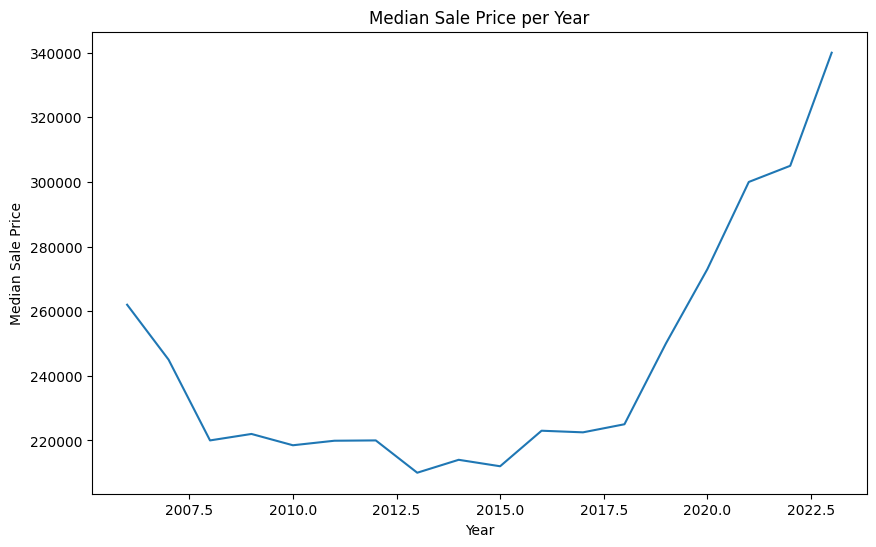

In [ ]:
# Line chart w/ median sale price per year
import matplotlib.pyplot as plt
cleaned_df.groupby('List Year')['Sale Amount'].median().plot(kind='line', figsize=(10, 6))
plt.title('Median Sale Price per Year')
plt.xlabel('Year')
plt.ylabel('Median Sale Price')
plt.show()

# makes sense, i'd have to confirm it makes sense with the events each year

This code creates a line chart of the median **`Sale Amount`** for each **`List Year`**. The data is grouped by year, the median sale price is calculated, and then it’s plotted with years on the x-axis and prices on the y-axis.  

The trend in the chart makes sense when compared with real-world events. There’s a sharp drop starting around 2007–2008, which lines up with the housing market crash and financial crisis. Prices then stay relatively flat for most of the 2010s, reflecting a slow recovery in the market. Starting around 2018, prices rise quickly and continue climbing through 2023. That spike matches factors like low interest rates, increased demand for housing, and the impacts of the COVID-19 pandemic, which drove competition and pushed prices up to record highs.


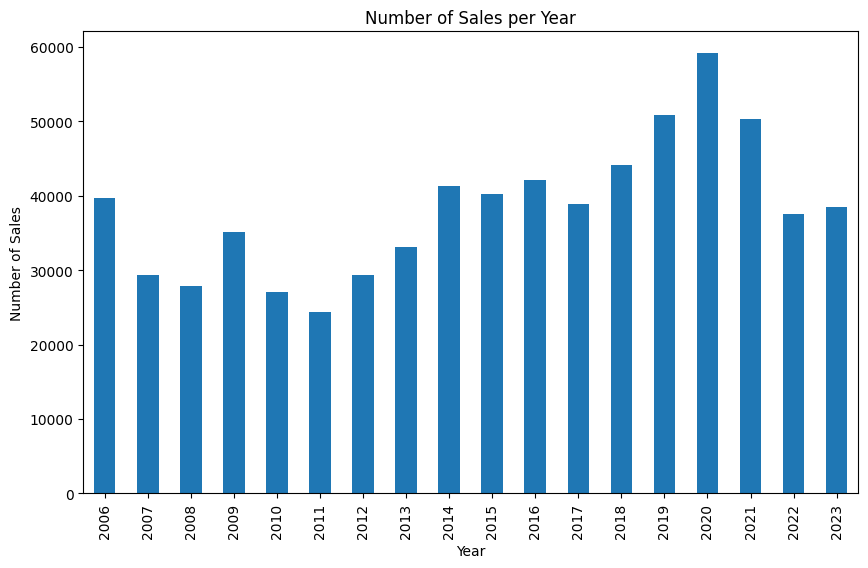

In [ ]:
# Bar chart w/ number of sales per year.
cleaned_df.groupby('List Year')['Sale Amount'].count().plot(kind='bar', figsize=(10, 6))
plt.title('Number of Sales per Year')
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.show()

#this makes sense to me, there was a demand for housing since people had to be inside for covid

This code makes a bar chart of the number of property sales for each **`List Year`**. It counts how many sales happened each year and then plots those totals.  

From the chart, you can see sales dropped during the recession in the late 2000s, then picked up through the 2010s. There’s a big jump in 2020 when the pandemic hit, since lots of people were moving, taking advantage of low interest rates, or looking for more space. After that, the numbers fall again in 2022 and 2023 as higher interest rates and affordability issues slowed the market.


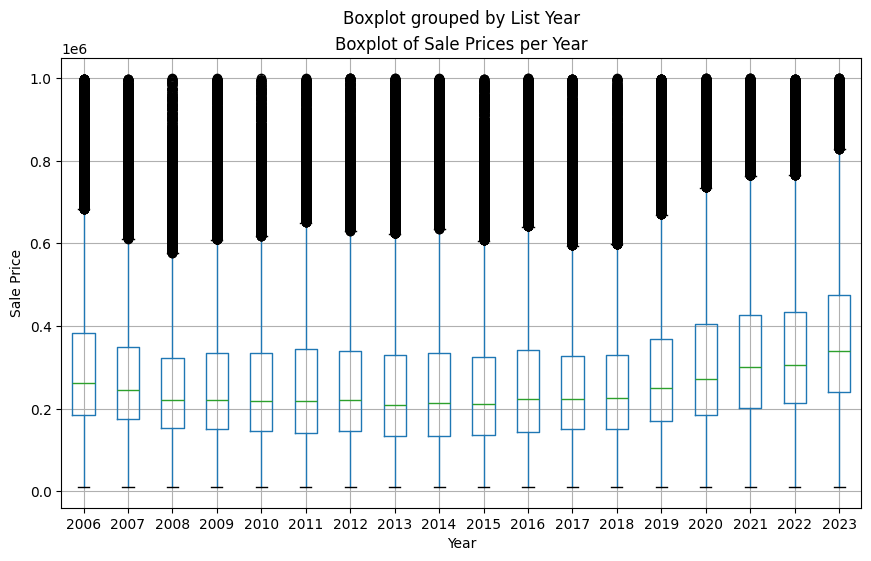

In [ ]:
# Boxplot (per year)
cleaned_df.boxplot(column='Sale Amount', by='List Year', figsize=(10, 6))
plt.title('Boxplot of Sale Prices per Year')
plt.xlabel('Year')
plt.ylabel('Sale Price')
plt.show()

# expected results. it shows inflations and hows the boxes sit much lower than the outliers

This code makes a boxplot of **`Sale Amount`** for each **`List Year`**. A boxplot shows how the prices are spread out: the box itself captures the middle range of sales, the line in the box is the median, and the dots above are outliers.  

From the chart, you can see that the boxes sit much lower than the outliers, which means most homes sold for far less than the very expensive ones at the top. Over time, the boxes shift upward, showing prices rising year by year. The tall stretch of outliers also highlights how a small number of very expensive homes pull away from the rest of the market.


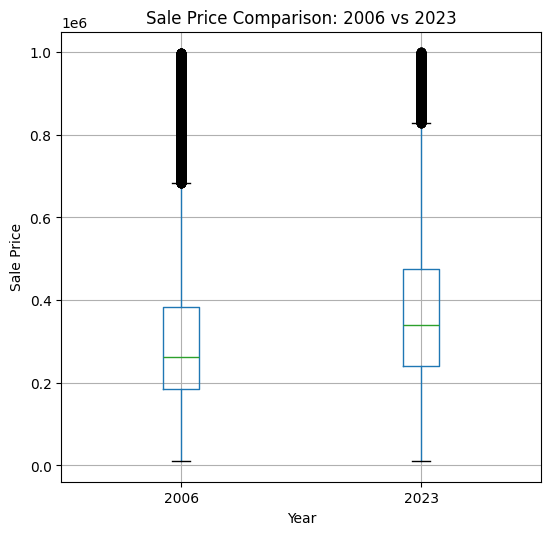

In [ ]:
# Compare 2006 vs 2023

comparison = cleaned_df[cleaned_df['List Year'].isin([2006, 2023])]

comparison.boxplot(column='Sale Amount', by='List Year', figsize=(6, 6))
plt.title('Sale Price Comparison: 2006 vs 2023')
plt.suptitle('')
plt.xlabel('Year')
plt.ylabel('Sale Price')
plt.show()

# expected results, looking at the big picture.


This code compares **`Sale Amount`** in 2006 and 2023 using boxplots. It filters the data to just those years and shows them side by side.  

The chart makes it clear that prices in 2023 are higher than in 2006. The whole box sits higher, meaning the typical home costs more now, and the range of prices is wider too. Outliers show up in both years, but the main takeaway is how much the market has changed over time.


#### **Early Descriptive Analysis of Housing Data**



The housing data visualizations highlight several noticeable trends over time. Certain years, such as 2008–2009, reflect the impact of the housing market crash, while more recent years show a strong upward shift in prices. Overall, the data suggests a consistent long-term increase in housing prices with a few periods of volatility. The patterns indicate that Connecticut’s housing market has become more expensive over time, especially in the years following the pandemic, where sale prices appear to rise sharply. These visualizations provide a clear picture of how the housing market has evolved and where significant changes have occurred.


---

#### **Visualizing Income Data**

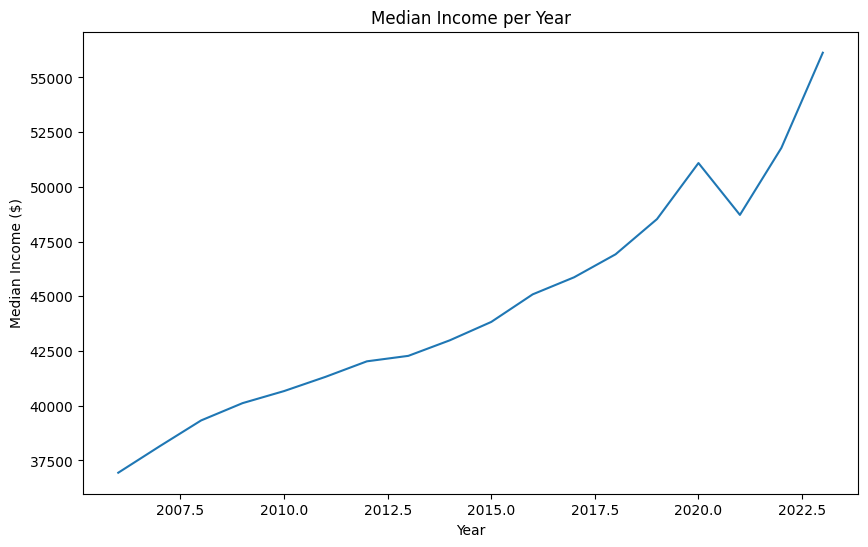

In [ ]:
#Median income per year
incomes.groupby('year')['a_median'].mean().plot(kind='line', figsize=(10,6))
plt.title("Median Income per Year")
plt.xlabel("Year")
plt.ylabel("Median Income ($)")
plt.show()

This code creates a line chart of the median annual income from **`incomes`**. It groups by **`year`**, takes the median **`a_median`**, and plots the results. The chart shows how wages in Connecticut have risen steadily from 2006 to 2023. The increases are gradual and steady, unlike the more volatile swings in housing prices. This highlights the slower growth of salaries compared to the housing market.


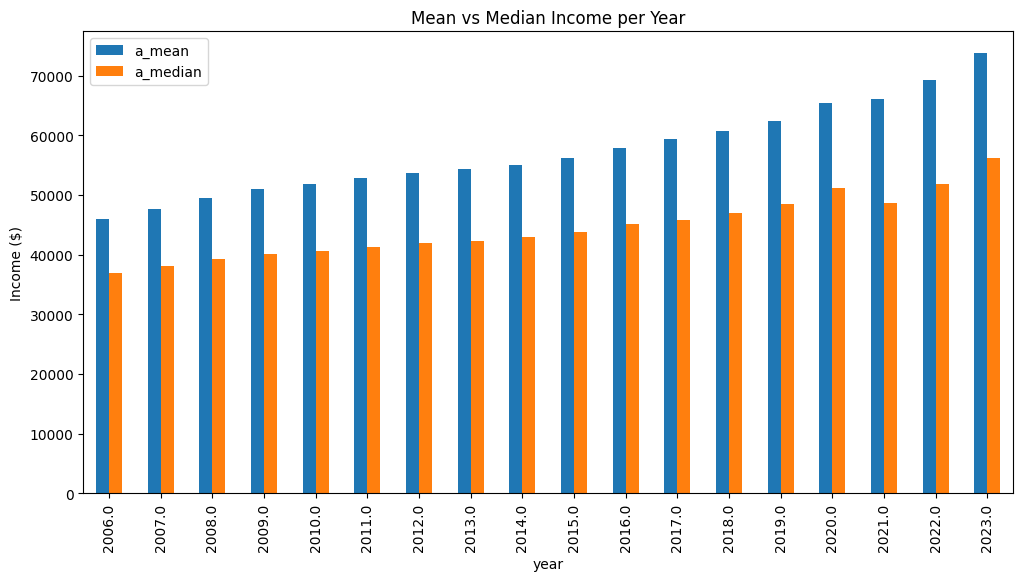

In [ ]:
#Compare mean vs median income per year

import seaborn as sns

incomes[['year', 'a_mean', 'a_median']].set_index('year').plot(kind='bar', figsize=(12,6))
plt.title("Mean vs Median Income per Year")
plt.ylabel("Income ($)")
plt.show()

This code compares **`a_mean`** and **`a_median`** from incomes in a bar chart. Every year, the mean is higher than the median, showing that a smaller number of high earners raise the average. The difference between mean and median reflects income inequality, and it explains why the median is often a better measure of what a “typical” worker earns when looking at affordability.

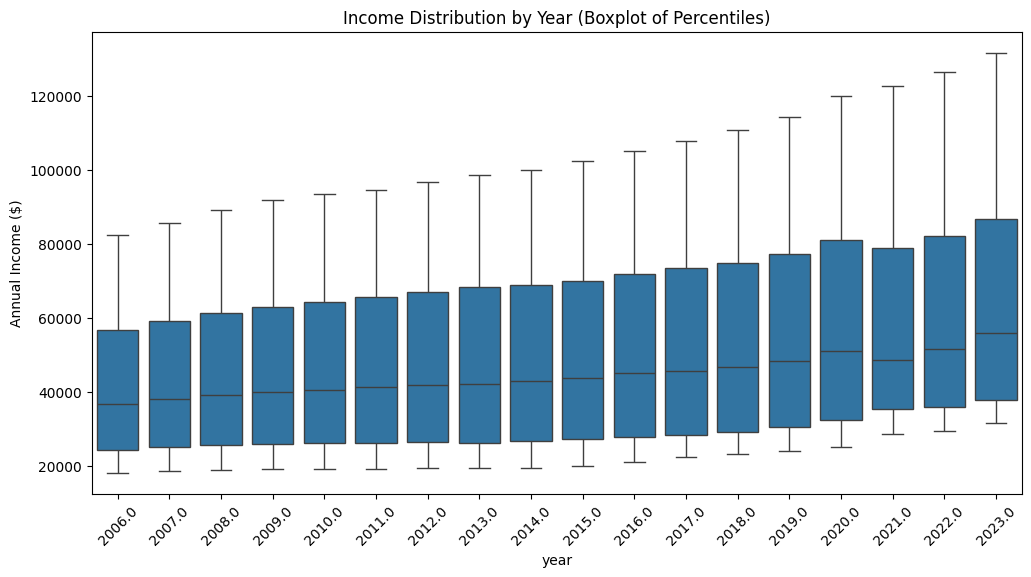

In [ ]:
#per-year boxplots
percentiles = incomes.melt(
    id_vars='year',
    value_vars=['a_pct10','a_pct25','a_median','a_pct75','a_pct90'],
    var_name='Percentile',
    value_name='Income'
)

plt.figure(figsize=(12,6))
sns.boxplot(data=percentiles, x='year', y='Income')
plt.title("Income Distribution by Year (Boxplot of Percentiles)")
plt.ylabel("Annual Income ($)")
plt.xticks(rotation=45)
plt.show()

This code reshapes the income percentiles (**`a_pct10`**, **`a_pct25`**, **`a_median`**, **`a_pct75`**, **`a_pct90`**) from incomes and plots them as a boxplot for each year. The visualization shows how incomes are spread across the population. The bottom percentiles remain far below the median, while the upper percentiles pull away more sharply over time. This highlights the inequality in earnings growth, with the top income groups gaining more than those at the bottom.

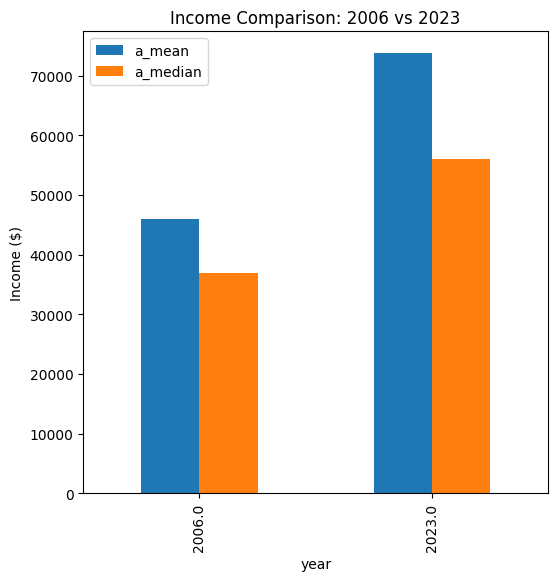

In [ ]:
#Focused comparison: 2006 vs 2023
import seaborn as sns
import matplotlib.pyplot as plt

comparison = incomes[incomes['year'].isin([2006, 2023])]
comparison[['year','a_mean','a_median']].set_index('year').plot(kind='bar', figsize=(6,6))
plt.title("Income Comparison: 2006 vs 2023")
plt.ylabel("Income ($)")
plt.show()

This code filters incomes to only include **`year`** = 2006 and **`year`** = 2023. It then plots **`a_mean`** and **`a_median`** side by side. The chart shows how both the average and median incomes have grown across nearly two decades. While incomes are higher in 2023, this direct comparison sets the stage for analyzing whether that growth is enough to keep pace with housing price increases.

#### **Early Descriptive Analysis of Income Data**

The income data visualizations reveal gradual but uneven changes in earnings across the analyzed years. While both mean and median incomes have increased over time, the rate of growth appears slower compared to inflation and living costs. Certain years show modest jumps, but others indicate relative stagnation, especially in the lower percentiles. These visuals illustrate how wage growth has varied, with higher earners generally seeing more consistent increases. Overall, the income data suggests that while Connecticut’s earnings have improved, they may not be keeping pace with the rising costs reflected in the housing data.


---

#### **Early Visualization of both sets of Data**

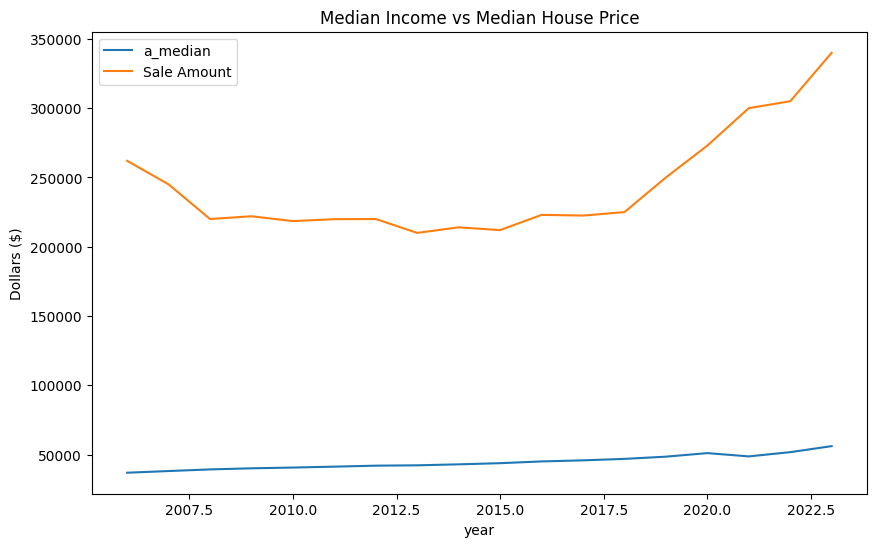

In [ ]:
#First aggregate housing by year (median sale amount)
house_by_year = cleaned_df.groupby('List Year', as_index=False)['Sale Amount'].median()

#Merge with income
merged = incomes.merge(house_by_year, left_on='year', right_on='List Year')

#Median income vs median house price
merged.plot(x='year', y=['a_median','Sale Amount'], figsize=(10,6))
plt.title("Median Income vs Median House Price")
plt.ylabel("Dollars ($)")
plt.show()


This code merges **`incomes`** with **`cleaned_df`** (grouped by **`List Year`**) so that the median **`a_median`** income can be compared directly to the median **`Sale Amount`** each year. The line chart shows that while income has steadily increased, the growth rate is slow compared to house prices. From around 2018 onward, the line for **`Sale Amount`** rises sharply while **`a_median`** stays relatively flat. This illustrates the growing affordability gap, where housing prices are outpacing wages.

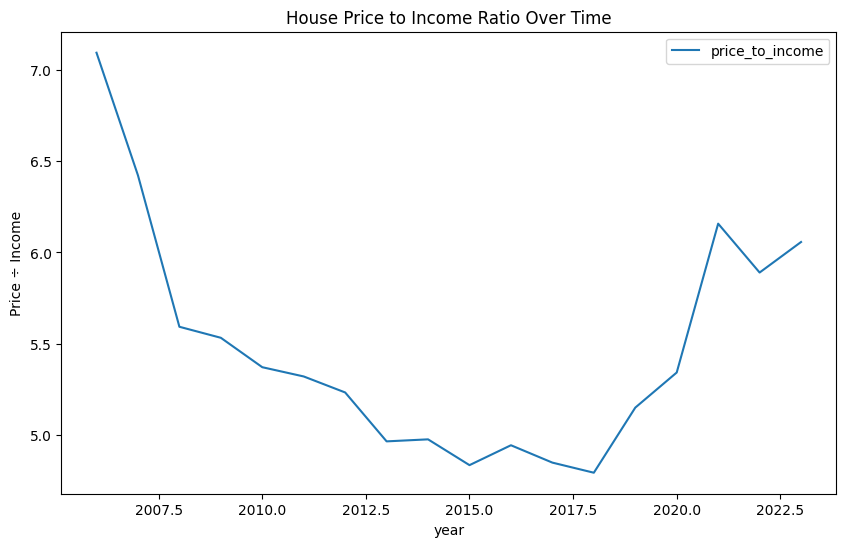

In [ ]:
#Housing affordability index (price-to-income)
merged['price_to_income'] = merged['Sale Amount'] / merged['a_median']
merged.plot(x='year', y='price_to_income', kind='line', figsize=(10,6))
plt.title("House Price to Income Ratio Over Time")
plt.ylabel("Price ÷ Income")
plt.show()

This code calculates a new column in the merged dataset by dividing **`Sale Amount`** by **`a_median`**, producing a **`price_to_income`** ratio. The line chart shows how many years of median income it would take to purchase a median-priced home. In the mid-2010s, the ratio was lower, meaning homes were relatively more affordable. After 2020, the ratio jumps upward again, showing that affordability worsened significantly during the pandemic and beyond, as housing costs rose faster than wages.

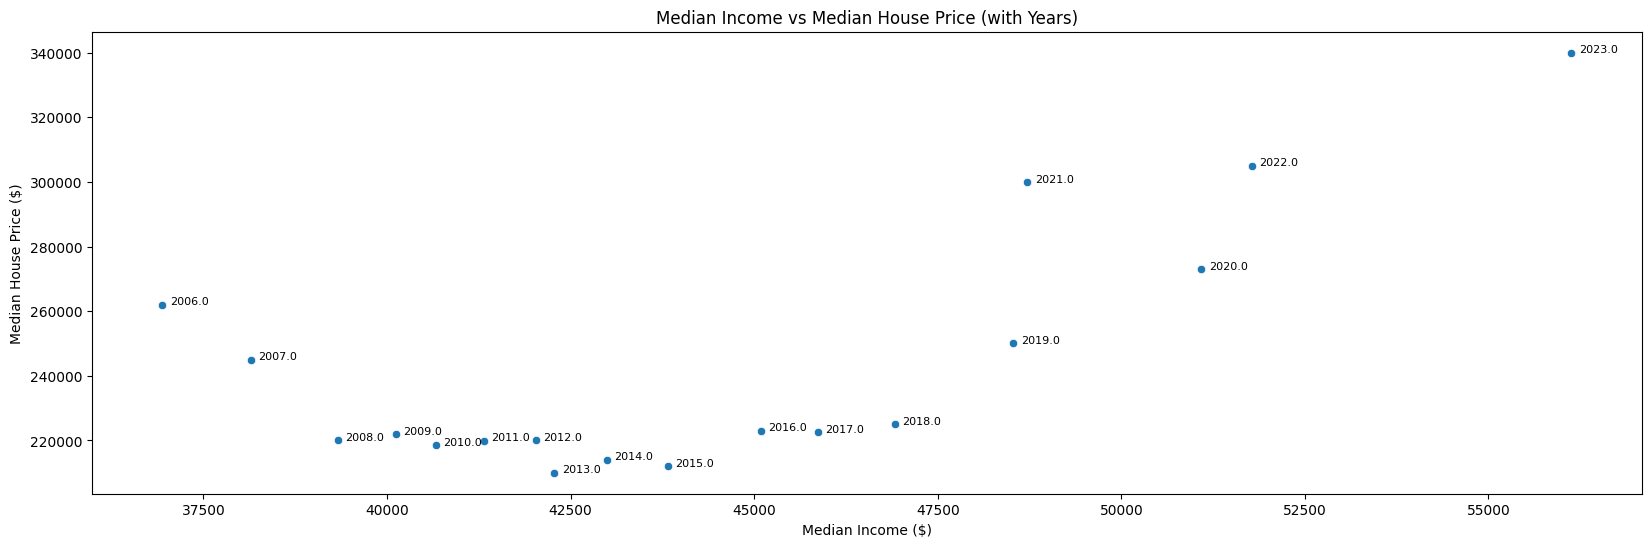

In [ ]:
#Income vs House Prices
plt.figure(figsize=(20,6))
sns.scatterplot(data=merged, x='a_median', y='Sale Amount')

for i, row in merged.iterrows():
    plt.text(row['a_median']+100, row['Sale Amount'], row['year'], fontsize=8)

plt.title("Median Income vs Median House Price (with Years)")
plt.xlabel("Median Income ($)")
plt.ylabel("Median House Price ($)")
plt.show()

This code makes a scatter plot using **`a_median`** (income) on the x-axis and **`Sale Amount`** (house price) on the y-axis from the merged dataset. Each point is labeled with its **`year`**, so the reader can follow the progression over time. The chart shows that while incomes gradually rise, housing prices climb much faster, especially after 2018. The path of points bends steeply upward in recent years, highlighting the widening gap between wages and home costs. Adding year labels makes it clear how affordability has shifted over time instead of just showing a static correlation.

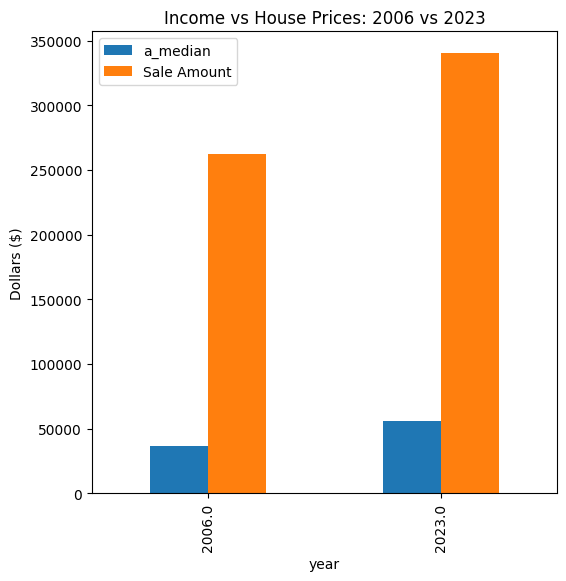

In [ ]:
#2006 vs 2023
comparison = merged[merged['year'].isin([2006, 2023])]
comparison[['year','a_median','Sale Amount']].set_index('year').plot(kind='bar', figsize=(6,6))
plt.title("Income vs House Prices: 2006 vs 2023")
plt.ylabel("Dollars ($)")
plt.show()

This code filters the merged dataset to only include **`year`** = 2006 and **`year`** = 2023, then plots **`a_median`** and **`Sale Amount`** side by side. The comparison makes the long-term change very clear: while income has grown somewhat, house prices have risen dramatically. The much taller orange bar for **`Sale Amount`** in 2023 shows how much faster housing costs have climbed compared to wages, illustrating why affordability is such a concern.

#### **Early Descriptive Analysis of both sets of Data**

When comparing the housing and income data together, clear differences begin to emerge. The relationship between rising housing prices and slower income growth is especially visible when comparing early years, such as 2006, to recent ones like 2023. While income has increased over time, housing costs appear to have risen at a much faster rate, indicating a growing affordability gap. These early comparisons suggest that homeownership and cost of living may have become increasingly difficult for the average resident. This section provides a strong foundation for deeper analysis in the next phase, where statistical comparisons and combined visualizations can further clarify the scale of this disparity.


---

### **Current Status (Ending Progress check 1)**

The housing and income datasets have been fully cleaned, organized, and prepared for analysis. Visualizations were created to highlight initial trends within each dataset, including yearly fluctuations in home sale prices and income levels. Early findings indicate noticeable variations across the years, with certain periods reflecting clear economic impacts such as rapid housing growth and later declines. These visuals provide a strong foundation for identifying patterns and disparities between income and housing trends in future stages of analysis.



### **Left To Do**

#### **Left To Do (For Reference)**
* Conduct a comparative analysis of the cleaned income and housing datasets to identify disparities and percentage differences between the two, as well as their respective inflation and growth rates from 2006 to 2023.

* Apply statistical and visual analysis techniques—such as correlation and trendline modeling—to evaluate the relationship between income growth and housing price increases across the study period.

* Examine whether the rate of housing price growth in Connecticut has consistently outpaced income growth, thereby contributing to reduced housing affordability for the middle class.

* Generate visualizations and summary tables that clearly depict yearly disparities, percentage changes, and inflation-adjusted comparisons.

* Interpret the results to draw conclusions regarding long-term affordability trends and discuss potential socioeconomic implications.

* Prepare a concise summary section to synthesize key findings and highlight areas for future research or policy consideration.

---
## **8. Progess Check II**




### **Outline**

#### **Design Decisions**
* Integrated U.S. inflation rate data to adjust both income and housing prices into constant dollars, allowing for more accurate affordability comparisons over time.
* Developed a comparative analysis showing the relationship between yearly housing growth and income growth, highlighting affordability gaps.
* Added forecasting models (linear regression) to project affordability trends through 2029.
* Built a merged monthly dataset combining housing, income, and inflation data from 2006–2023, serving as the foundation for future predictive modeling.

#### **Overall Design**
* Expanded the analysis to include inflation-adjusted comparisons, capturing real affordability trends over time.
* Visualized correlation and growth patterns to show how housing prices and income move relative to each other.
* Produced forecasted affordability visualizations to assess potential future outcomes.
* Constructed a complete data pipeline that merges, cleans, and rebases all key metrics, ensuring the dataset is ready for further predictive and visual analysis.

#### **System Implementation**
* The project now integrates three datasets:
  1. Housing Data – Monthly median sale prices (2006–2023)
  2. Income Data – Median annual income, expanded to monthly frequency
  3. Inflation Data – U.S. Inflation Rate, merged yearly
* The pipeline performs:
  - Cleaning and alignment of time ranges across datasets  
  - Inflation adjustments to 2023 constant dollars  
  - Computation of affordability metrics such as price-to-income ratios and growth rates  
  - Preparation of features for model development and future evaluations

#### **How the Design Satisfies User Needs**
* The target users, policymakers, housing researchers, and middle-class residents, need clear, data-driven insights into affordability trends.
* The inflation-adjusted results and forecasts help users understand how rapidly housing costs have outpaced income in real terms.
* The modeling and visualizations offer a forward-looking tool for predicting affordability changes and potential policy needs.

#### **Current Status**
* All datasets have been cleaned, merged, and inflation-adjusted.
* Visualizations showing affordability trends, correlation patterns, and growth rate comparisons are complete.
* The merged monthly-level dataset is finalized and ready for additional model testing and evaluation.

#### **Left To Do**
* Prepare the Summary Section with project title, author name, and final visualizations.
* Develop a concise narrative of findings and conclusions for the Final Report.
* Create and embed a YouTube presentation demonstrating project insights in under 10 minutes.
* Review all visuals and interpretations for clarity and alignment with final report expectations.
* Complete the Final Report and Demo submission by December 5.


### **Comparing Yearly Inflation Rates to Yearly Incrome Growth**

In [ ]:
# Import Interest Rate Dataset
interest = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/yearly_interest_rates.csv")

# Display Head
display(interest.head())

# Change the column name FPCPITOTLZGUSA to US Inflation Rate
interest = interest.rename(columns={'FPCPITOTLZGUSA': 'US Inflation Rate'})

# Change the column name observation_date to Year
interest = interest.rename(columns={'observation_date': 'Year'})

# Convert the 'Year' column to datetime objects and then extract the year
interest['Year'] = pd.to_datetime(interest['Year']).dt.year

# Display Head
display(interest.head())

,observation_date,FPCPITOTLZGUSA
0,2006-01-01,3.225944
1,2007-01-01,2.852672
2,2008-01-01,3.839100
3,2009-01-01,-0.355546
4,2010-01-01,1.640043


,Year,US Inflation Rate
0,2006,3.225944
1,2007,2.852672
2,2008,3.839100
3,2009,-0.355546
4,2010,1.640043


This code loads a yearly inflation CSV, previews it, standardizes the column names (renaming **`FPCPITOTLZGUSA`** to **`US Inflation Rate`** and **`observation_date`** to **`Year`**), then converts the date column into a plain year (e.g., 2006, 2007). A final preview confirms the tidy two-column frame (**`Year`**, **`US Inflation Rate`**), making it ready to merge on **`Year`** with other datasets for year-based analysis.

In [ ]:
# Turn Year Column datatype to a int64 dtype
interest['Year'] = pd.to_numeric(interest['Year'], errors='coerce').astype('Int64')
merged['year']   = pd.to_numeric(merged['year'],  errors='coerce').astype('Int64')

print("Data type of 'year' in merged DataFrame:")
display(merged['year'].dtype)
print("\nUnique values in 'year' in merged DataFrame:")
display(merged['year'].unique())

# Print Column names
print("\nColumn names in interest DataFrame:")
display(interest.columns)

print("\nData type of 'Year' in interest DataFrame:")
display(interest['Year'].dtype)

print("\nUnique values in 'Year' in interest DataFrame:")
display(interest['Year'].unique())

Data type of 'year' in merged DataFrame:


Int64Dtype()


Unique values in 'year' in merged DataFrame:


<IntegerArray>
[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
 2019, 2020, 2021, 2022, 2023]
Length: 18, dtype: Int64


Column names in interest DataFrame:


Index(['Year', 'US Inflation Rate'], dtype='object')


Data type of 'Year' in interest DataFrame:


Int64Dtype()


Unique values in 'Year' in interest DataFrame:


<IntegerArray>
[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
 2019, 2020, 2021, 2022, 2023, 2024]
Length: 19, dtype: Int64

This code normalizes the join keys by converting both **`interest['Year']`** and **`merged['year']`** to pandas' nullable integers (**`Int64`**), coercing any invalid entries to **`NA`**. It then sanity-checks the result: printing the **`dtype`** and unique values for **`merged['year']`**, and showing the **`interest`** column names plus the **`Year`** dtype and its unique values. Together, these checks confirm both sides share the same integer year domain, reducing merge mismatches before joining on year.

In [ ]:
# Merge the interest DataFrame with the merged DataFrame
merged_inflation = merged.merge(interest, left_on='year', right_on='Year', how='left')

# Drop the redundant 'Year' column from the merged_inflation DataFrame
merged_inflation = merged_inflation.drop('Year', axis=1)

# Change Column name 'year' to 'Year'
merged_inflation = merged_inflation.rename(columns={'year': 'Year'})

# Display the head of the new DataFrame
display(merged_inflation.head())

,Year,state,occ_title,a_mean,a_pct10,a_pct25,a_median,a_pct75,a_pct90,List Year,Sale Amount,price_to_income,US Inflation Rate
0,2006,Connecticut,All Occupations,45970.0,18280.0,24330.0,36940.0,56880.0,82430.0,2006,262000.0,7.092583,3.225944
1,2007,Connecticut,All Occupations,47680.0,18670.0,25080.0,38150.0,59170.0,85620.0,2007,245000.0,6.422018,2.852672
2,2008,Connecticut,All Occupations,49530.0,19080.0,25870.0,39330.0,61460.0,89190.0,2008,220000.0,5.593694,3.839100
3,2009,Connecticut,All Occupations,50950.0,19180.0,26050.0,40120.0,63170.0,91940.0,2009,222000.0,5.533400,-0.355546
4,2010,Connecticut,All Occupations,51920.0,19290.0,26240.0,40670.0,64260.0,93450.0,2010,218500.0,5.372510,1.640043


This code enriches the main dataset with inflation by left-merging on the year keys (**`merged.year`** ↔ **`interest.Year`**), keeping all original rows. It then removes the duplicate Year from the right table, standardizes the key name by renaming **`year`** to **`Year`**, and previews the result to confirm that **`US Inflation Rate`** is now attached to each year.



In [ ]:
# Add inflation-adjusted price_to_income column
merged_inflation["Price_to_Income_adj"] = (
    merged_inflation["price_to_income"] / (1 + merged_inflation["US Inflation Rate"] / 100)
).round(6)

# (Optional) Display to confirm
display(merged_inflation[["Year", "price_to_income", "US Inflation Rate", "Price_to_Income_adj"]].head())


,Year,price_to_income,US Inflation Rate,Price_to_Income_adj
0,2006,7.092583,3.225944,6.870930
1,2007,6.422018,2.852672,6.243900
2,2008,5.593694,3.839100,5.386886
3,2009,5.533400,-0.355546,5.553144
4,2010,5.372510,1.640043,5.285821



### **Income/Housing Price Gap Prediction Model**

In [ ]:
# Copy dataframes into new dataframes
housing = cleaned_df.copy()
income  = incomes.copy()
inflation = merged_inflation.copy()

This code creates fresh working copies of three source DataFrames so later edits won't affect the originals. It copies:

*  **`cleaned_df`** → **`housing`**
*  **`incomes`** → **`income`**
*  **`merged_inflation`** → **`inflation`**

Using **`.copy()`** ensures subsequent cleaning, merging, or feature engineering on **`housing`**, **`income`**, and **`inflation`** is isolated from the original datasets.

### **Upload Preprocessed Datasets**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

# Read Data into Datasets
housing = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/Cleaned Datasets/cleaned_housing_data.csv")
income = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/Cleaned Datasets/cleaned_income_data.csv")
merged = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/Cleaned Datasets/merged_housing_income_data.csv")
inflation = pd.read_csv("/content/gdrive/My Drive/DASC620_Group_Project/Cleaned Datasets/merged_inflation_data.csv")

# Display Heads for all Datasets
print("Housing Data Head:")
display(housing.head(5))
print("\n")
print("\nIncome Data Head:")
display(income.head(5))
print("\n")
print("\nMerged Data Head:")
display(merged.head(5))
print("\n")
print("\nMerged Inflation Data Head:")
display(inflation.head(5))

Mounted at /content/gdrive
Housing Data Head:


,Serial Number,List Year,Date Recorded,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,60681,2006,05/21/2007,230860.0,350000.0,0.659600,Single Family,Single Family
1,60320,2006,08/21/2007,151120.0,220000.0,0.686909,Single Family,Single Family
2,60298,2006,02/01/2007,169960.0,230000.0,0.738957,Two Family,Two Family
3,60315,2006,05/03/2007,348200.0,480000.0,0.725417,Single Family,Single Family
4,60010,2006,10/13/2006,245000.0,387000.0,0.633075,Single Family,Single Family





Income Data Head:


,year,state,occ_title,a_mean,a_pct10,a_pct25,a_median,a_pct75,a_pct90
0,2006.0,Connecticut,All Occupations,45970.0,18280.0,24330.0,36940.0,56880.0,82430.0
1,2007.0,Connecticut,All Occupations,47680.0,18670.0,25080.0,38150.0,59170.0,85620.0
2,2008.0,Connecticut,All Occupations,49530.0,19080.0,25870.0,39330.0,61460.0,89190.0
3,2009.0,Connecticut,All Occupations,50950.0,19180.0,26050.0,40120.0,63170.0,91940.0
4,2010.0,Connecticut,All Occupations,51920.0,19290.0,26240.0,40670.0,64260.0,93450.0





Merged Data Head:


,year,state,occ_title,a_mean,a_pct10,a_pct25,a_median,a_pct75,a_pct90,List Year,Sale Amount,price_to_income,Income_Growth_Rate,Housing_Growth_Rate
0,2006,Connecticut,All Occupations,45970.0,18280.0,24330.0,36940.0,56880.0,82430.0,2006,262000.0,7.092583,NaN,NaN
1,2007,Connecticut,All Occupations,47680.0,18670.0,25080.0,38150.0,59170.0,85620.0,2007,245000.0,6.422018,3.275582,-6.488550
2,2008,Connecticut,All Occupations,49530.0,19080.0,25870.0,39330.0,61460.0,89190.0,2008,220000.0,5.593694,3.093054,-10.204082
3,2009,Connecticut,All Occupations,50950.0,19180.0,26050.0,40120.0,63170.0,91940.0,2009,222000.0,5.533400,2.008645,0.909091
4,2010,Connecticut,All Occupations,51920.0,19290.0,26240.0,40670.0,64260.0,93450.0,2010,218500.0,5.372510,1.370887,-1.576577





Merged Inflation Data Head:


,Year,state,occ_title,a_mean,a_pct10,a_pct25,a_median,a_pct75,a_pct90,List Year,Sale Amount,price_to_income,Income_Growth_Rate,Housing_Growth_Rate,US Inflation Rate,Inflation_Factor,Adj_House_Value,Adj_Income
0,2006,Connecticut,All Occupations,45970.0,18280.0,24330.0,36940.0,56880.0,82430.0,2006,262000.0,7.092583,NaN,NaN,3.225944,1.000000,262000.000000,36940.000000
1,2007,Connecticut,All Occupations,47680.0,18670.0,25080.0,38150.0,59170.0,85620.0,2007,245000.0,6.422018,3.275582,-6.488550,2.852672,1.061706,230760.589669,35932.720391
2,2008,Connecticut,All Occupations,49530.0,19080.0,25870.0,39330.0,61460.0,89190.0,2008,220000.0,5.593694,3.093054,-10.204082,3.839100,1.102466,199552.567512,35674.556728
3,2009,Connecticut,All Occupations,50950.0,19180.0,26050.0,40120.0,63170.0,91940.0,2009,222000.0,5.533400,2.008645,0.909091,-0.355546,1.098547,202085.188103,36520.980841
4,2010,Connecticut,All Occupations,51920.0,19290.0,26240.0,40670.0,64260.0,93450.0,2010,218500.0,5.372510,1.370887,-1.576577,1.640043,1.116563,195689.763233,36424.268516


### **Merging & Cleaning Datasets for Feature Preparation**

In [ ]:
import pandas as pd

housing["Date Recorded"] = pd.to_datetime(housing["Date Recorded"], errors="coerce")
housing["Year"] = housing["Date Recorded"].dt.year
housing["Month"] = housing["Date Recorded"].dt.month

# Compute monthly median sale price
housing_monthly = (
    housing.groupby(["Year", "Month"])["Sale Amount"]
    .median()
    .reset_index()
    .rename(columns={"Sale Amount": "Median_House_Price"})
)

print(housing_monthly.head())

# Print Total Rows
print("Total Rows:", len(housing_monthly))

# Display Dataframe in descending order
print("\nHousing Monthly Dataframe in Descending Order:")
display(housing_monthly.sort_values(by="Year", ascending=False))

     Year  Month  Median_House_Price
0  1999.0    4.0             95000.0
1  2001.0    8.0            596500.0
2  2001.0    9.0            256000.0
3  2001.0   10.0            660000.0
4  2003.0    7.0            158900.0
Total Rows: 232

Housing Monthly Dataframe in Descending Order:


,Year,Month,Median_House_Price
224,2024.0,2.0,315000.0
230,2024.0,8.0,367500.0
229,2024.0,7.0,360000.0
228,2024.0,6.0,372000.0
227,2024.0,5.0,350000.0
...,...,...,...
4,2003.0,7.0,158900.0
2,2001.0,9.0,256000.0
3,2001.0,10.0,660000.0
1,2001.0,8.0,596500.0


This code prepares and summarizes monthly housing prices. It converts **`"Date Recorded"`** to a datetime, extracts **`Year`** and **`Month`**, then groups by these to compute the median **`"Sale Amount"`** per month. The result is a tidy table **`housing_monthly`** with columns **`Year`**, **`Month`**, and **`Median_House_Price`**. It prints the first few rows, reports the total number of monthly records, and finally displays the full DataFrame sorted in descending order by **`Year`** for a quick top-down review.

In [ ]:
# Get Monthly Median Income values for Prediction Model
income["year"] = income["year"].astype(int)
monthly_income = (
    income.loc[income["state"] == "Connecticut", ["year", "a_median"]]
    .rename(columns={"year": "Year", "a_median": "Median_Income"})
)

# Repeat each income value for all 12 months of that year
monthly_income = (
    monthly_income
    .merge(pd.DataFrame({"Month": range(1, 13)}), how="cross")
    .sort_values(["Year", "Month"])
)

print(monthly_income.head(15))

# Display Total Rows
print("Total Rows:", len(monthly_income))

# Display in Descending Order
print("\nMonthly Income Dataframe in Descending Order:")
display(monthly_income.sort_values(by="Year", ascending=False))

    Year  Median_Income  Month
0   2006        36940.0      1
1   2006        36940.0      2
2   2006        36940.0      3
3   2006        36940.0      4
4   2006        36940.0      5
5   2006        36940.0      6
6   2006        36940.0      7
7   2006        36940.0      8
8   2006        36940.0      9
9   2006        36940.0     10
10  2006        36940.0     11
11  2006        36940.0     12
12  2007        38150.0      1
13  2007        38150.0      2
14  2007        38150.0      3
Total Rows: 216

Monthly Income Dataframe in Descending Order:


,Year,Median_Income,Month
211,2023,56130.0,8
210,2023,56130.0,7
209,2023,56130.0,6
208,2023,56130.0,5
207,2023,56130.0,4
...,...,...,...
11,2006,36940.0,12
3,2006,36940.0,4
2,2006,36940.0,3
1,2006,36940.0,2


This code prepares a monthly income dataset for use in the prediction model. It first converts the **`year`** column to an integer type and filters the data to include only records for **Connecticut**. It then renames the columns to **`Year`** and **`Median_Income`** for consistency.

Next, it expands the dataset so that each annual income value is repeated for all 12 months of that year by performing a cross-merge with a DataFrame containing **`Month`** values from 1 to 12. This creates a complete monthly time series where each month inherits the same income value from its respective year.

Finally, the code prints the first 15 rows for verification, displays the total number of rows, and shows the full DataFrame sorted in descending order by **`Year`** for easy inspection.

In [ ]:
# Ensure housing 'Year' is numeric
housing_monthly["Year"] = pd.to_numeric(housing_monthly["Year"], errors="coerce").astype(int)

# Drop housing rows outside the income range
min_year = income["year"].min()
max_year = income["year"].max()

housing_monthly = housing_monthly[
    (housing_monthly["Year"] >= min_year) & (housing_monthly["Year"] <= max_year)
].reset_index(drop=True)

print(f"Filtered housing data: {housing_monthly['Year'].min()} → {housing_monthly['Year'].max()}")
print("Total Rows:", len(housing_monthly))

# Display Dataframe in descending order
print("\nHousing Monthly Dataframe in Descending Order:")
display(housing_monthly.sort_values(by="Year", ascending=False))

Filtered housing data: 2006 → 2023
Total Rows: 211

Housing Monthly Dataframe in Descending Order:


,Year,Month,Median_House_Price
201,2023,3.0,290000.0
200,2023,2.0,279250.0
199,2023,1.0,280000.0
206,2023,8.0,330000.0
205,2023,7.0,340000.0
...,...,...,...
2,2006,8.0,336000.0
5,2006,11.0,253000.0
4,2006,10.0,258187.5
6,2006,12.0,257500.0


This code aligns the housing dataset's time range with the income dataset to ensure both cover the same years for analysis or modeling.

It first converts the **`Year`** column in **`housing_monthly`** to a numeric integer type to prevent type mismatches. Then, it retrieves the minimum and maximum years from the **`income`** dataset and filters **`housing_monthly`** to keep only rows within that range. The filtered DataFrame is reset with a clean index.

Finally, the code prints the new year range and total number of remaining rows, then displays the dataset sorted in descending order by **`Year`**. This step ensures consistency between the housing and income data before merging or feature generation.

In [ ]:
import pandas as pd
import numpy as np

# --- 0) Canonical year range from income (2006..2023) ---
income["year"] = pd.to_numeric(income["year"], errors="coerce").astype(int)
min_year, max_year = income["year"].min(), income["year"].max()

# --- 1) Clean housing monthly & restrict to income range ---
housing_monthly["Year"]  = pd.to_numeric(housing_monthly["Year"],  errors="coerce").astype(int)
housing_monthly["Month"] = pd.to_numeric(housing_monthly["Month"], errors="coerce").astype(int)
housing_monthly = housing_monthly[
    (housing_monthly["Year"] >= min_year) & (housing_monthly["Year"] <= max_year)
].copy()

# --- 2) Build complete Year×Month grid and join housing ---
grid = (
    pd.MultiIndex.from_product([range(min_year, max_year+1), range(1, 13)],
                               names=["Year", "Month"])
    .to_frame(index=False)
)
housing_full = grid.merge(housing_monthly, on=["Year", "Month"], how="left")

# Diagnostics: see which months are missing housing values
missing_tail = housing_full[housing_full["Median_House_Price"].isna()].tail(15)

# --- 3) Expand income to all months (repeat each year’s value for 12 months) ---
income_ct = income.copy()
if "state" in income_ct.columns:
    income_ct = income_ct[income_ct["state"].eq("Connecticut")]
if "occ_title" in income_ct.columns:
    income_ct = income_ct[income_ct["occ_title"].eq("All Occupations")]

# Prefer a_median, else a_mean
income_col = "a_median" if "a_median" in income_ct.columns else "a_mean"
income_monthly = (
    income_ct[["year", income_col]]
      .rename(columns={"year": "Year", income_col: "Median_Income"})
      .merge(pd.DataFrame({"Month": range(1, 13)}), how="cross")
      .sort_values(["Year", "Month"])
      .reset_index(drop=True)
)

# --- 4) Merge income into the full grid ---
merged = housing_full.merge(income_monthly, on=["Year", "Month"], how="left")

# --- 5) Merge inflation (yearly) ---
inflation["Year"] = pd.to_numeric(inflation["Year"], errors="coerce").astype(int)
inflation["US Inflation Rate"] = pd.to_numeric(inflation["US Inflation Rate"], errors="coerce")
merged = merged.merge(inflation[["Year", "US Inflation Rate"]], on="Year", how="left")

# --- 6) Inflation-adjust to constant dollars (rebase to last year in data) ---
merged = merged.sort_values(["Year", "Month"]).reset_index(drop=True)
# yearly inflation → cumulative price index by Year (apply same index to all months of that year)
year_idx = (
    merged[["Year", "US Inflation Rate"]]
    .drop_duplicates()
    .assign(infl_factor=lambda d: 1 + d["US Inflation Rate"].fillna(0)/100.0)
    .sort_values("Year")
)
year_idx["price_index"] = year_idx["infl_factor"].cumprod()
merged = merged.merge(year_idx[["Year", "price_index"]], on="Year", how="left")

base_idx = float(year_idx.loc[year_idx["Year"].eq(max_year), "price_index"].iloc[0])
merged["rebase_factor"] = base_idx / merged["price_index"]

merged["House_Const$"]  = (merged["Median_House_Price"] * merged["rebase_factor"]).round(2)
merged["Income_Const$"] = (merged["Median_Income"]      * merged["rebase_factor"]).round(2)
merged["Gap_Const$"]    = (merged["House_Const$"] - merged["Income_Const$"]).round(2)
merged["Price_to_Income_Const"] = (merged["House_Const$"] / merged["Income_Const$"])

# --- 7) Handle missing housing months (choose ONE strategy) ---

# (A) Leave as NaN and drop before modeling:
merged_na_report = merged[merged["Median_House_Price"].isna()][["Year","Month"]]

# --- 8) Quick sanity checks ---
print("Last 6 rows (check 2023 months present):")
print(merged.sort_values(["Year","Month"]).tail(6)[["Year","Month","Median_House_Price","Median_Income"]])

print("\nMissing housing months near the end (if any):")
print(missing_tail)

Last 6 rows (check 2023 months present):
     Year  Month  Median_House_Price  Median_Income
210  2023      7            340000.0        56130.0
211  2023      8            330000.0        56130.0
212  2023      9            325000.0        56130.0
213  2023     10            329900.0        56130.0
214  2023     11            325000.0        56130.0
215  2023     12            325000.0        56130.0

Missing housing months near the end (if any):
   Year  Month  Median_House_Price
0  2006      1                 NaN
1  2006      2                 NaN
2  2006      3                 NaN
3  2006      4                 NaN
4  2006      5                 NaN


This code builds a fully merged, inflation-adjusted dataset that aligns housing, income, and inflation data on a consistent monthly timeline — ready for modeling or analysis. It performs cleaning, alignment, merging, and feature engineering in multiple structured steps:

---


**Step 0**: Define the Canonical Year Range

*   Converts the **`year`** column in the income data to integers.
*   Determines the overall **minimum** and **maximum** years available (e.g., 2006–2023).
*   These years define the consistent time range to be used for all datasets.

---

**Step 1**: Clean and Restrict the Housing Data
*   Ensures the **`Year`** and **`Month`** columns in **`housing_monthly`** are numeric.
*   Filters the dataset so it only includes years within the income range.
*   Keeps data consistent across both datasets before merging.

---

**Step 2**: Build a Complete Year-Month Grid
*   Creates a full grid of all possible **`(Year, Month)`** combinations within the chosen range using **`pd.MultiIndex.from_product()`**.
*   Merges this grid with **`housing_monthly`** to fill in any missing months, ensuring a continuous time series (even if some months have no housing data).
*   Stores missing entries for diagnostic checking in **`missing_tail`**.

---

**Step 3**: Expand Income Data to Monthly Frequency
*   Copies and filters the **`income`** dataset to include only Connecticut and the **`"All Occupations"`** category.
*   Selects the best available income column (**`a_median`** preferred, otherwise **`a_mean`**).
*   Repeats each annual median income value for all 12 months of that year using a cross merge, creating a monthly version of the income dataset (**`income_monthly`**).

---

**Step 4**: Merge Income and Housing Data
* Combines **`income_monthly`** with the full **`(Year, Month)`** housing grid to produce a unified monthly dataset containing both **Median_House_Price** and **Median_Income**.

---

**Step 5**: Add Inflation Data
*   Cleans and converts inflation columns (**`Year`**, **`US Inflation Rate`**) to numeric values.
*   Merges inflation data yearly into the combined dataset so each month of a given year carries the same inflation rate.

---

**Step 6**: Adjust for Inflation (Convert to Constant Dollars)
*   Sorts by **`Year`** and **`Month`** for proper chronological order.
*   Builds a cumulative price index (**`price_index`**) from annual inflation rates to account for compounded inflation over time.
*   Rebases all monetary values to the last available year (e.g., 2023) using a rebase factor.
*   Calculates inflation-adjusted metrics:
    *   **`House_Const$`** — Real (constant-dollar) house price
    *   **`Income_Const$`** — Real median income
    *   **`Gap_Const$`** — Difference between constant-dollar house price and income
    *   **`Price_to_Income_Const`** — Inflation-adjusted price-to-income ratio

---

**Step 7**: Handle Missing Housing Data
*   Identifies any months that still lack **`Median_House_Price`** values, storing them in **`merged_na_report`** for review.

---

**Step 8**: Sanity Checks
*   Prints the **last 6 rows** to confirm the dataset includes all recent months (e.g., full 2023 coverage).
*   Displays any missing housing months at the tail end of the dataset (**`missing_tail`**) for quick validation.

---

**Summary**
*   This pipeline produces a **comprehensive monthly dataset** (2006-2023) that merges housing, income, and inflation data into a single frame with inflation-adjusted values. It ensures temporal consistency, fills missing months, computes real-dollar metrics, and prepares the data for predictive modeling, time series analysis, or affordability trend evaluation.

In [ ]:
# Display housing_full
print("housing_full:")
display(housing_full.head())

# Display Income Monthly
print("\nincome_monthly:")
display(income_monthly.head())

# Display Housing Monthly
print("\nhousing_monthly:")
display(housing_monthly.head())

housing_full:


,Year,Month,Median_House_Price
0,2006,1,NaN
1,2006,2,NaN
2,2006,3,NaN
3,2006,4,NaN
4,2006,5,NaN



income_monthly:


,Year,Median_Income,Month
0,2006,36940.0,1
1,2006,36940.0,2
2,2006,36940.0,3
3,2006,36940.0,4
4,2006,36940.0,5



housing_monthly:


,Year,Month,Median_House_Price
0,2006,6,210875.0
1,2006,7,323000.0
2,2006,8,336000.0
3,2006,9,851250.0
4,2006,10,258187.5


This code displays a quick preview of three key DataFrames used in the data preparation process.

It first prints a label and shows the first few rows of each dataset using **`display()`** for easier visual inspection:

*   **`housing_full`** - the complete Year-Month grid of housing data, including any months filled in during preprocessing.
*   **`income_monthly`** - the expanded income dataset where each year's income value is repeated across all 12 months.
*   **`housing_monthly`** - the cleaned and filtered dataset containing monthly median house prices before merging.

In [ ]:
import pandas as pd
import numpy as np

# Start from your 'merged' DataFrame
filled = merged.copy()

# Make sure index is simple and time columns are clean
filled = filled.reset_index(drop=True)
filled["Year"]  = pd.to_numeric(filled["Year"], errors="coerce").astype(int)
filled["Month"] = pd.to_numeric(filled["Month"], errors="coerce").astype(int)

# Sort so forward/back fill is chronological within each year
filled = filled.sort_values(["Year", "Month"]).reset_index(drop=True)

# Use transform to preserve index alignment (avoids the TypeError)
filled["Median_House_Price"] = (
    filled.groupby("Year")["Median_House_Price"]
          .transform(lambda s: s.ffill().bfill())
)

# Recompute constant-$ columns after filling
filled["House_Const$"]  = (filled["Median_House_Price"] * filled["rebase_factor"]).round(2)
filled["Gap_Const$"]    = (filled["House_Const$"] - filled["Income_Const$"]).round(2)
filled["Price_to_Income_Const"] = (filled["House_Const$"] / filled["Income_Const$"])

# Optional quick checks
print(filled.tail(6)[["Year","Month","Median_House_Price","Median_Income"]])
print("\nNaNs left in price/const columns?")
print(filled[["Median_House_Price","House_Const$","Income_Const$","Gap_Const$"]].isna().sum())

# Get Rows
print("\nTotal Rows:", len(filled))

# Get Columns
print("\nTotal Columns:", len(filled.columns))

     Year  Month  Median_House_Price  Median_Income
210  2023      7            340000.0        56130.0
211  2023      8            330000.0        56130.0
212  2023      9            325000.0        56130.0
213  2023     10            329900.0        56130.0
214  2023     11            325000.0        56130.0
215  2023     12            325000.0        56130.0

NaNs left in price/const columns?
Median_House_Price    0
House_Const$          0
Income_Const$         0
Gap_Const$            0
dtype: int64

Total Rows: 216

Total Columns: 11


This code cleans and fills missing monthly housing prices, ensuring the dataset is complete and ready for analysis or modeling.

It begins by copying the **`merged`** DataFrame into **`filled`** to preserve the original data. Then it resets the index, converts **`Year`** and **`Month`** to numeric integers, and sorts the dataset chronologically to maintain proper order for time-based operations.

Next, it fills in missing values for **`Median_House_Price`** **within each year** using both forward fill (**`ffill()`**) and backward fill (**`bfill()`**), ensuring no gaps remain in the monthly housing prices.

After filling, the code recalculates inflation-adjusted (constant-dollar) columns:
*   **`House_Const$`** — inflation-adjusted house price
*   **`Gap_Const$`** — difference between real house price and real income
*   **`Price_to_Income_Const`** — inflation-adjusted affordability ratio

Finally, it performs quick diagnostics — printing the last few rows, checking for any remaining NaN values, and reporting the total number of rows and columns.
Overall, this ensures the dataset is fully filled, inflation-adjusted, and consistent for further feature engineering or regression modeling.

### **Visualizations**

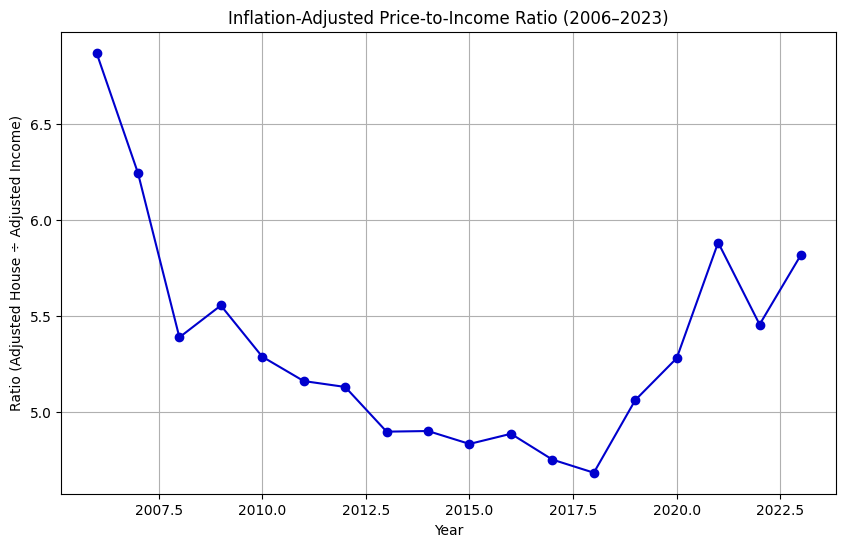

In [ ]:
# Plot the ratio
plt.figure(figsize=(10,6))
plt.plot(
    merged_inflation['Year'],
    merged_inflation['Price_to_Income_adj'],
    marker='o',
    color='mediumblue'
)
plt.title('Inflation-Adjusted Price-to-Income Ratio (2006–2023)')
plt.xlabel('Year')
plt.ylabel('Ratio (Adjusted House ÷ Adjusted Income)')
plt.grid(True)
plt.show()

#### **Comparative Analysis of Housing and Income Data**

This section visualizes how Connecticut housing prices and average occupational income have changed over time.  
We also calculate and visualize the percentage difference between the two to track affordability trends.

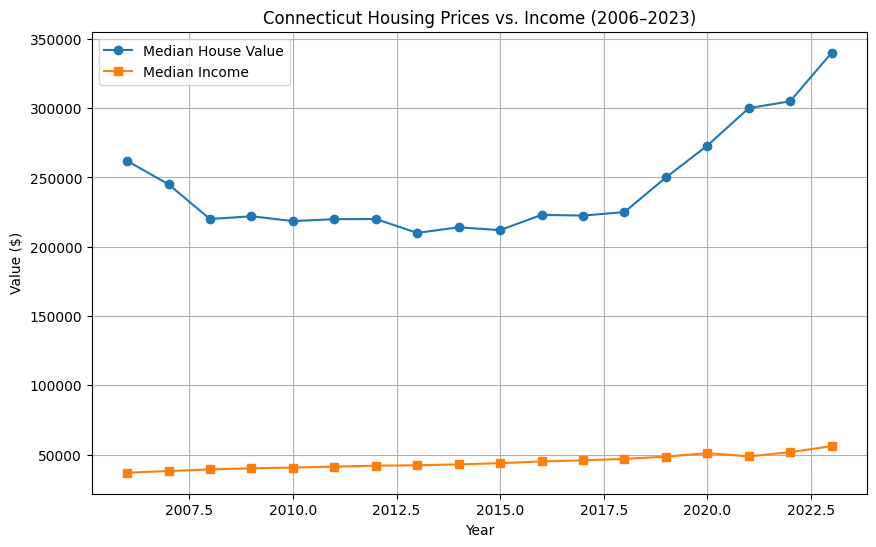

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(merged['year'], merged['Sale Amount'], marker='o', label='Median House Value')
plt.plot(merged['year'], merged['a_median'], marker='s', label='Median Income')
plt.title('Connecticut Housing Prices vs. Income (2006–2023)')
plt.xlabel('Year')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True)
plt.show()


This visualization plots the median housing price and median income in Connecticut from 2006 to 2023. While both increase slightly over time, housing prices rise at a much faster rate, especially after 2018. During the late 2000s and mid-2010s, housing prices dipped and remained relatively stable, reflecting the 2008 housing crash and recovery period. After 2020, prices surged sharply, outpacing income growth. The widening gap between the two lines illustrates worsening affordability, households’ earnings have not kept up with the cost of purchasing a home.

In [ ]:
# Show me all the columns from merged
merged.columns

Index(['year', 'state', 'occ_title', 'a_mean', 'a_pct10', 'a_pct25',
       'a_median', 'a_pct75', 'a_pct90', 'List Year', 'Sale Amount',
       'price_to_income'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


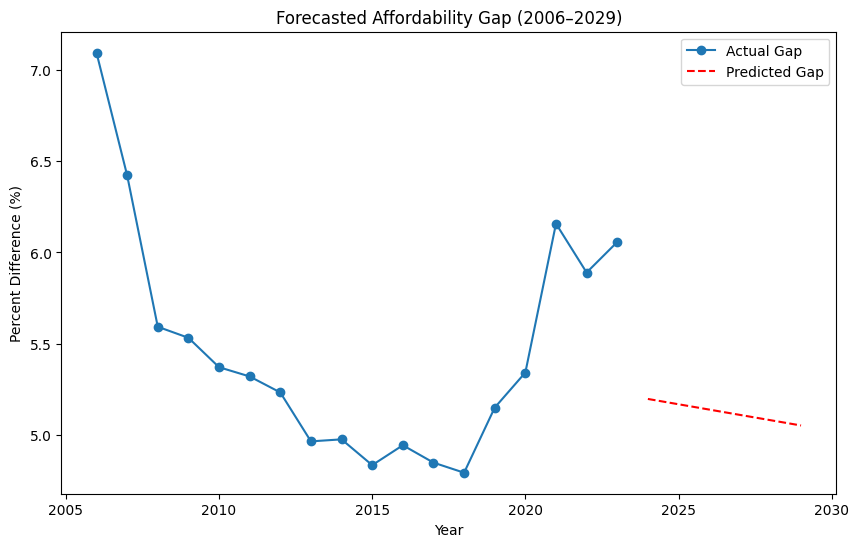

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = merged[['year']]
y = merged['price_to_income']

model = LinearRegression().fit(X, y)
future_years = np.array(range(2024, 2030)).reshape(-1, 1)
predicted_gaps = model.predict(future_years)

plt.figure(figsize=(10,6))
plt.plot(merged['year'], y, marker='o', label='Actual Gap')
plt.plot(future_years.flatten(), predicted_gaps, linestyle='--', color='red', label='Predicted Gap')
plt.title('Forecasted Affordability Gap (2006–2029)')
plt.xlabel('Year')
plt.ylabel('Percent Difference (%)')
plt.legend()
plt.show()


This code uses a simple linear regression model to predict future affordability gaps, measured as the percentage difference between median house prices and median incomes. The blue line shows the actual historical gap, while the red dashed line projects values for 2024–2029. The forecast indicates that although the gap may slightly narrow, housing is still expected to remain several hundred percent higher than income levels. This projection suggests that unless income growth accelerates, affordability challenges will likely persist or worsen in the coming years.

#### **Forecasting Affordability Trends**

This section models and visualizes predicted affordability gaps for future years.  

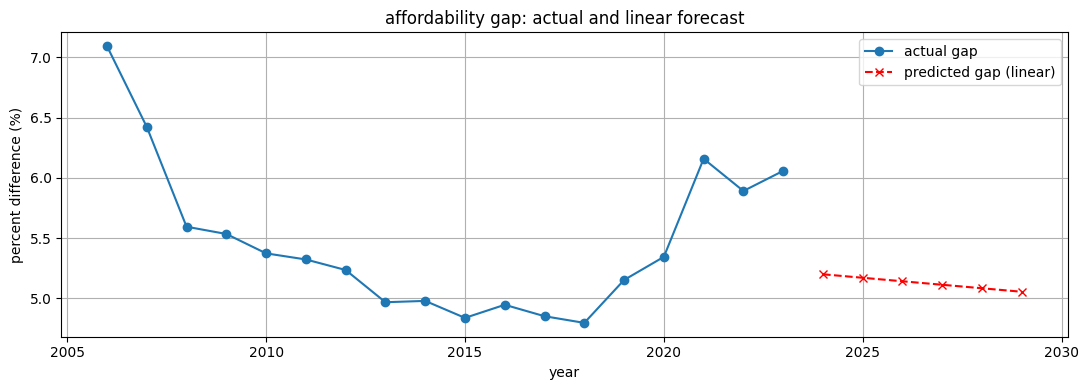

linear model slope: -0.029 intercept: 63.955


In [ ]:
import numpy as np

from sklearn.linear_model import LinearRegression
X = merged[['year']].values
y = merged['price_to_income'].values
lr = LinearRegression().fit(X, y)

future_years = np.arange(2024, 2030).reshape(-1,1)
predicted = lr.predict(future_years)

plt.figure(figsize=(11,4))
plt.plot(merged['year'], y, marker='o', label='actual gap')
plt.plot(future_years.flatten(), predicted, linestyle='--', color='red', marker='x', label='predicted gap (linear)')
plt.title('affordability gap: actual and linear forecast')
plt.xlabel('year'); plt.ylabel('percent difference (%)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# quick model info
print('linear model slope:', lr.coef_[0].round(4), 'intercept:', lr.intercept_.round(3))

This code uses a simple linear regression model to predict future affordability gaps, measured as the percentage difference between median house prices and median incomes. The blue line shows the actual historical gap, while the red dashed line projects values for 2024–2029. The forecast indicates that although the gap may slightly narrow, housing is still expected to remain several hundred percent higher than income levels. This projection suggests that unless income growth accelerates, affordability challenges will likely persist or worsen in the coming years.

#### **Statistical Relationship Between Income Growth and Housing Price Growth**

This section applies correlation and trendline modeling to visualize how closely income growth aligns with housing price growth.  

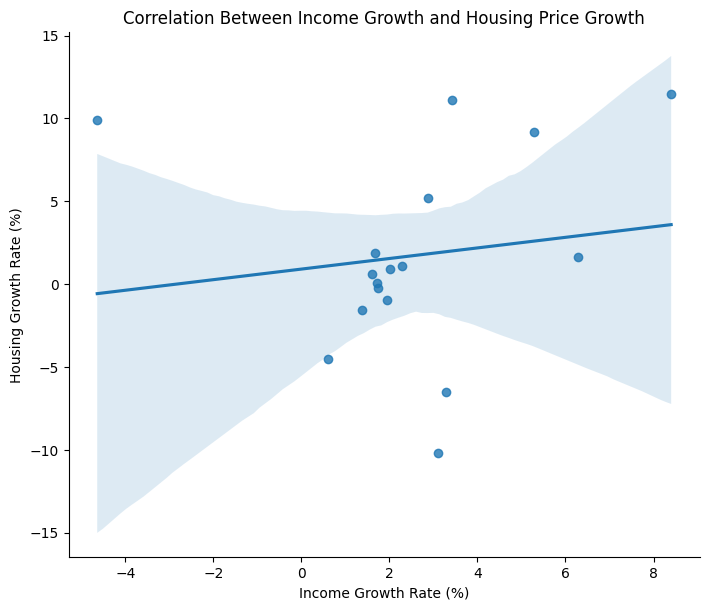

In [ ]:
merged['Income_Growth_Rate'] = merged['a_median'].pct_change() * 100
merged['Housing_Growth_Rate'] = merged['Sale Amount'].pct_change() * 100

sns.lmplot(data=merged, x='Income_Growth_Rate', y='Housing_Growth_Rate', height=6, aspect=1.2)
plt.title('Correlation Between Income Growth and Housing Price Growth')
plt.xlabel('Income Growth Rate (%)')
plt.ylabel('Housing Growth Rate (%)')
plt.show()

This code calculates year-over-year percentage changes in both median income and housing prices, then plots them to examine whether income gains keep pace with rising home values. The scatterplot with a fitted trendline shows a weak positive correlation, meaning that when incomes rise, housing prices tend to rise too, but not proportionally. The wide confidence band and scattered points suggest that housing prices often outpace income growth, reinforcing the overall theme of worsening affordability in Connecticut.

#### **Inflation-Adjusted Housing and Income Comparison**

This section adjusts both housing prices and incomes for inflation to evaluate real affordability changes over time.  

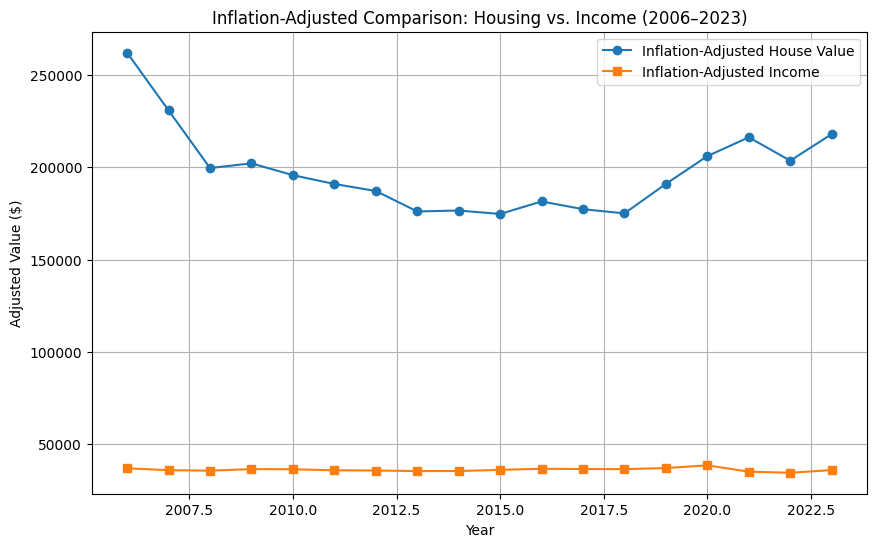

In [ ]:
# Merge the interest DataFrame with the merged DataFrame
merged_inflation = merged.merge(interest, left_on='year', right_on='Year', how='left')

# Drop the redundant 'Year' column from the merged_inflation DataFrame
merged_inflation = merged_inflation.drop('Year', axis=1)

# Change Column name 'year' to 'Year'
merged_inflation = merged_inflation.rename(columns={'year': 'Year'})

# Use the US Inflation Rate to calculate an inflation factor
# Assuming the inflation rate is the percentage change from the previous year
# We'll need to calculate a cumulative inflation factor relative to a base year (e.g., 2006)
merged_inflation['Inflation_Factor'] = (1 + merged_inflation['US Inflation Rate'] / 100).cumprod()

# For the base year (2006), the inflation factor should be 1
merged_inflation.loc[merged_inflation['Year'] == 2006, 'Inflation_Factor'] = 1.0

# Adjust Housing and Income values for inflation
merged_inflation['Adj_House_Value'] = merged_inflation['Sale Amount'] / merged_inflation['Inflation_Factor']
merged_inflation['Adj_Income'] = merged_inflation['a_median'] / merged_inflation['Inflation_Factor']

plt.figure(figsize=(10,6))
plt.plot(merged_inflation['Year'], merged_inflation['Adj_House_Value'], label='Inflation-Adjusted House Value', marker='o')
plt.plot(merged_inflation['Year'], merged_inflation['Adj_Income'], label='Inflation-Adjusted Income', marker='s')
plt.title('Inflation-Adjusted Comparison: Housing vs. Income (2006–2023)') # Modified title
plt.xlabel('Year')
plt.ylabel('Adjusted Value ($)')
plt.legend()
plt.grid(True)
plt.show()

This code adjusts both median housing prices and median incomes for inflation using the U.S. Inflation Rate data. It calculates a cumulative inflation factor relative to the base year (2006) and then divides the nominal house values and incomes by this factor to get their real, inflation-adjusted values. The resulting plot shows the trend of housing prices and income in constant 2006 dollars, revealing that even after accounting for inflation, housing prices have increased at a significantly faster rate than income over the study period, especially in recent years.

#### **Growth Rates of Housing Prices vs. Income Over Time**

This section visualizes yearly growth rates to compare how quickly housing prices and income have changed.  

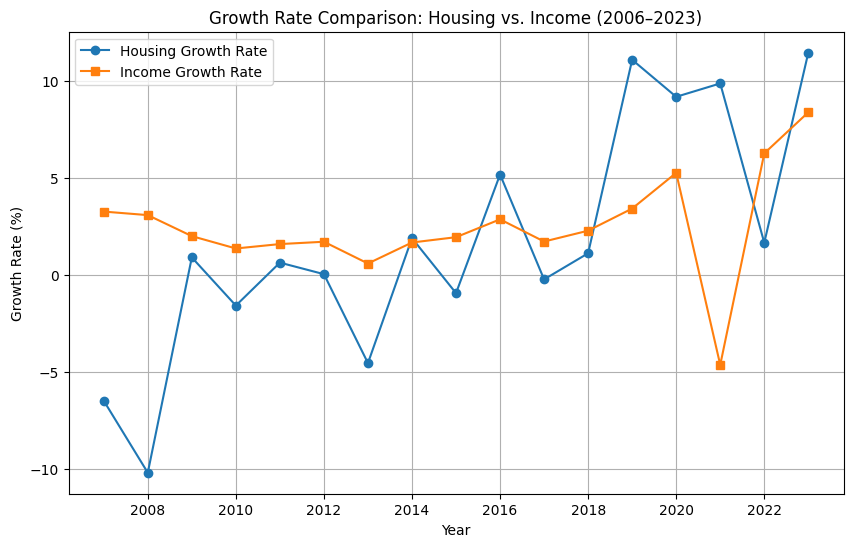

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(merged_inflation['Year'], merged_inflation['Housing_Growth_Rate'], label='Housing Growth Rate', marker='o')
plt.plot(merged_inflation['Year'], merged_inflation['Income_Growth_Rate'], label='Income Growth Rate', marker='s')
plt.title('Growth Rate Comparison: Housing vs. Income (2006–2023)')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

This code plots year-over-year growth rates for both housing prices and median income to reveal how quickly each has changed over time. The line chart shows that housing growth has been far more volatile, with sharper peaks and dips, and significant increases, especially after 2018. In contrast, income growth remained steadier and generally lower. This comparison demonstrates that even when wages rise, housing prices often grow at a much faster and more unpredictable rate, contributing to Connecticut’s ongoing housing affordability challenges.

### **Feature Preperation**

In [ ]:
import pandas as pd
import numpy as np

def _find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first matching column (case/space/underscore-insensitive)."""
    normmap = {c: c.strip().lower().replace("\xa0"," ").replace("_"," ").replace("%"," ") for c in df.columns}
    wanted  = [w.strip().lower().replace("\xa0"," ").replace("_"," ").replace("%"," ") for w in candidates]
    for raw, norm in normmap.items():
        if norm in wanted:
            return raw
    return None

def build_type_medians_monthly(housing_raw: pd.DataFrame) -> pd.DataFrame:
    """Monthly median Sale Amount by Residential Type (one row per Year-Month)."""
    hh = housing_raw.copy()
    if "Date Recorded" in hh.columns:
        hh["Date Recorded"] = pd.to_datetime(hh["Date Recorded"], errors="coerce")
        hh["Year"]  = hh["Date Recorded"].dt.year
        hh["Month"] = hh["Date Recorded"].dt.month
    else:
        if "List Year" not in hh.columns or "Month" not in hh.columns:
            raise KeyError("housing_raw needs 'Date Recorded' OR both 'List Year' and 'Month'")
        hh["Year"]  = pd.to_numeric(hh["List Year"], errors="coerce").astype("Int64")
        hh["Month"] = pd.to_numeric(hh["Month"], errors="coerce").astype("Int64")

    hh["Sale Amount"] = pd.to_numeric(hh["Sale Amount"], errors="coerce")

    type_m = (
        hh.groupby(["Year","Month","Residential Type"])["Sale Amount"]
          .median()
          .unstack(fill_value=np.nan)
          .add_prefix("Median_")
          .reset_index()
    )
    return type_m

def _looks_like_infl(c):
    t = c.replace('\xa0',' ').replace('_',' ').strip().lower()
    return ("inflation" in t) or ("cpi" in t and "yoy" in t)

filled = filled.drop(columns=[c for c in filled.columns if _looks_like_infl(c)], errors="ignore")

def build_features_monthly(
    filled: pd.DataFrame,          # must have: Year, Month, Median_House_Price, Median_Income
    inflation: pd.DataFrame,       # has Year + inflation rate column (annual or monthly)
    housing_raw: pd.DataFrame|None = None,  # optional to add monthly per-type medians
    *,
    base_year: int|None = None     # default = last year present in data
) -> pd.DataFrame:
    """Return a monthly features DataFrame. No splitting or modeling here."""
    df = filled.copy()
    # Basic sanity
    need = ["Year","Month","Median_House_Price","Median_Income"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise KeyError(f"'filled' missing columns: {miss}")
    df["Year"]  = pd.to_numeric(df["Year"], errors="coerce").astype(int)
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce").astype(int)
    df = df.sort_values(["Year","Month"]).reset_index(drop=True)

    # Normalize inflation headers and detect columns
    inf = inflation.copy()
    inf.columns = (inf.columns
                     .str.replace('\xa0',' ', regex=False)
                     .str.replace(r'\s+',' ', regex=True)
                     .str.strip())
    year_col = _find_col(inf, ["Year","year"])
    infl_col = _find_col(inf, [
        "US Inflation Rate","Inflation Rate","US_Inflation_Rate","inflation_rate",
        "CPI YoY","Annual Inflation Rate","Inflation"
    ])
    if year_col is None or infl_col is None:
        raise KeyError(f"Could not find Year/inflation columns in inflation: {list(inf.columns)}")

    inf[year_col] = pd.to_numeric(inf[year_col], errors="coerce").astype(int)
    inf[infl_col] = pd.to_numeric(inf[infl_col], errors="coerce")

    # If monthly inflation present, aggregate to annual mean
    month_col = _find_col(inf, ["Month","month"])
    if month_col:
        inf_yearly = (inf.groupby(inf[year_col])[infl_col]
                        .mean().reset_index()
                        .rename(columns={year_col:"Year", infl_col:"US Inflation Rate"}))
    else:
        inf_yearly = inf[[year_col, infl_col]].rename(columns={year_col:"Year", infl_col:"US Inflation Rate"})

    # Merge annual inflation into monthly frame
    df = df.merge(inf_yearly, on="Year", how="left")

    # --- 2) COALESCE any inflation columns (handles _x/_y, extra spaces) ---
    def _norm(s: str) -> str:
        return s.replace('\xa0',' ').replace('_',' ').strip().lower()

    inflation_like = [
        c for c in df.columns
        if ("inflation" in _norm(c)) or ("cpi" in _norm(c) and "yoy" in _norm(c))
    ]

    if not inflation_like:
        raise KeyError(
            "No inflation column found after merge. "
            f"Columns: {list(df.columns)}"
    )

    # If multiple candidates (e.g., *_x/_y), coalesce left→right
    if len(inflation_like) > 1:
        df["US Inflation Rate"] = df[inflation_like].bfill(axis=1).iloc[:, 0]
        for c in inflation_like:
            if c != "US Inflation Rate":
                df.drop(columns=c, inplace=True, errors="ignore")
    else:
        if inflation_like[0] != "US Inflation Rate":
            df.rename(columns={inflation_like[0]: "US Inflation Rate"}, inplace=True)

    # --- 3) Build CPI-like price index by Year (map, not merge) ---
    year_idx = (
        df[["Year", "US Inflation Rate"]]
          .drop_duplicates()
          .sort_values("Year")
          .assign(infl_factor=lambda d: 1 + d["US Inflation Rate"].fillna(0)/100.0)
    )
    year_idx["price_index"] = year_idx["infl_factor"].cumprod()

    # Map ensures we always get a 'price_index' column (no suffix risks)
    idx_map = dict(zip(year_idx["Year"], year_idx["price_index"]))
    df["price_index"] = df["Year"].map(idx_map)

    # Safety checks (helpful while wiring)
    if df["price_index"].isna().any():
        missing_years = df.loc[df["price_index"].isna(), "Year"].unique().tolist()
        raise KeyError(f"'price_index' mapping produced NaNs for years: {missing_years}. "
                       f"Check inflation coverage for those years.")

    if base_year is None:
        base_year = int(df["Year"].max())

    # Get base index safely
    try:
        base_idx = float(year_idx.loc[year_idx["Year"].eq(base_year), "price_index"].iloc[0])
    except IndexError:
        raise KeyError(f"base_year {base_year} not present in inflation. "
                       f"Years available: {year_idx['Year'].tolist()}")

    df["rebase_factor"] = base_idx / df["price_index"]

    # Constant-dollar conversions
    df["House_Const$"]  = (df["Median_House_Price"] * df["rebase_factor"]).round(2)
    df["Income_Const$"] = (df["Median_Income"]      * df["rebase_factor"]).round(2)

    # Ratios/gaps
    df["Price_to_Income"]       = df["Median_House_Price"] / df["Median_Income"]
    df["Gap_Nominal"]           = df["Median_House_Price"] - df["Median_Income"]
    df["Price_to_Income_Const"] = df["House_Const$"] / df["Income_Const$"]
    df["Gap_Const$"]            = df["House_Const$"] - df["Income_Const$"]

    # MoM growth
    df["Income_Growth_Rate"]   = df["Median_Income"].pct_change() * 100
    df["Housing_Growth_Rate"]  = df["Median_House_Price"].pct_change() * 100
    df["Gap_Growth_Nominal_%"] = df["Gap_Nominal"].pct_change() * 100
    df["Gap_Growth_Const_%"]   = df["Gap_Const$"].pct_change() * 100

    # Lags & rolling (3 months)
    for lag in [1,2,3]:
        df[f"Gap_Const$_lag{lag}"] = df["Gap_Const$"].shift(lag)
        df[f"Price_to_Income_Const_lag{lag}"] = df["Price_to_Income_Const"].shift(lag)
    df["Gap_Const$_roll3_mean"] = df["Gap_Const$"].rolling(3, min_periods=2).mean()
    df["Gap_Const$_roll3_std"]  = df["Gap_Const$"].rolling(3, min_periods=2).std()

    # Optional: monthly per-type medians
    if housing_raw is not None:
        type_m = build_type_medians_monthly(housing_raw)
        df = df.merge(type_m, on=["Year","Month"], how="left")

    # Final cleanup (avoid inf/NaN for modeling later)
    df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return df, base_year

This code defines a complete feature-engineering pipeline that transforms raw housing, income, and inflation data into a clean, analysis-ready monthly dataset. It includes multiple helper functions and a main builder function:

---


1.   **`_find_col()`**:

*   A utility function that searches for a column name in a DataFrame, ignoring case, spaces, underscores, and special characters. It returns the first column that matches any of the provided candidate names.
*   **Purpose**: helps identify columns like “Year” or “Inflation Rate” even if headers vary slightly between datasets.

---

2.   **`build_type_medians_monthly()`**
*   This function computes monthly median sale prices by residential type.
    *   Ensures a proper **`Year`** and **`Month`** column (deriving from **`Date Recorded`** or existing columns).
    *  Converts “Sale Amount” values to numeric.
    *  Groups the data by **`Year`**, **`Month`**, and **`Residential Type`**, calculating the median sale amount for each group.
    *  Reshapes the output so each housing type becomes its own column (e.g., **`Median_Single Family`**, **`Median_Condo`**).
*  **Purpose**: produces an optional dataset that captures housing price trends by category.

---
3.  **`_looks_like_infl()`**
*   Detects inflation-related columns (those containing “inflation” or “CPI YoY”) so that redundant or mislabeled inflation data can be removed from earlier stages.
*   The following line removes any such duplicate inflation columns from **`filled`**.

---
4.  **`build_features_monthly()`**
*   This is the main function that integrates all data sources to create a monthly feature dataset for modeling.
*   Key steps:
    1.  **Validation & Setup**
        *  Ensures essential columns (**`Year`**, **`Month`**, **`Median_House_Price`**, **`Median_Income`**) exist and converts them to numeric. The data is then chronologically sorted.
    2.  **Inflation Normalization**
        *  Cleans and standardizes inflation column headers, then detects and extracts the correct year and inflation rate columns using **`_find_col()`**.
    3.  **Aggregation to Annual Inflation (if needed)**
        *  If monthly inflation is present, it computes the annual mean per year. Otherwise, it uses the provided annual data directly.
    4.  **Merging Inflation Data**
        *  Joins the inflation table to the monthly dataset and standardizes the inflation column name to “US Inflation Rate.”
    5.  **Building a Price Index**
        *  Computes a cumulative price index (**`price_index`**) using year-over-year inflation rates, establishing a base year for constant-dollar calculations.
    6.  **Constant-Dollar Conversion**
        *  Creates real (inflation-adjusted) versions of income and house prices:
            *  **`House_Const$`** and **`Income_Const$`** are rebased to constant dollars.
            *  Derived features such as **`Gap_Const$`** and **`Price_to_Income_Const`** are calculated.
    7.  **Growth Rates & Lag Features**
        *  Computes month-over-month growth rates for income, housing, and gaps, as well as lag and rolling statistics (1-3 months) to capture temporal trends.
    8.  **Optional Merge of Housing Type Medians**
        *  If raw housing data is provided, it merges in the per-type monthly medians created by **`build_type_medians_monthly()`**.
    9.  **Final Cleanup**
        *  Replaces infinite values, drops missing data, and resets the index. Returns both the cleaned DataFrame (**`features_df`**) and the **`base_year`**.
---

***Overall Purpose:***

*   Together, these functions transform diverse raw inputs—housing prices, incomes, and inflation data—into a unified, time-series feature dataset. The output is clean, inflation-adjusted, and rich with engineered variables (ratios, growth rates, rolling averages, and lags), making it suitable for regression or forecasting models analyzing housing affordability trends.





















In [ ]:
# Normalize inflation headers once (handles stray spaces/NBSP)
inflation = inflation.copy()
inflation.columns = (
    inflation.columns
    .str.replace('\xa0',' ', regex=False)
    .str.replace(r'\s+',' ', regex=True)
    .str.strip()
)

features_df, base_year = build_features_monthly(
    filled=filled,           # your 216-row monthly frame
    inflation=inflation,     # annual inflation table
    housing_raw=housing      # optional to add Median_* per type monthly
)

print("features_df shape:", features_df.shape, "| base_year:", base_year)
display(features_df.head())
display(features_df.columns)

features_df shape: (207, 30) | base_year: 2023


,Year,Month,Median_House_Price,Median_Income,price_index,rebase_factor,House_Const$,Income_Const$,Gap_Const$,Price_to_Income_Const,...,Price_to_Income_Const_lag2,Gap_Const$_lag3,Price_to_Income_Const_lag3,Gap_Const$_roll3_mean,Gap_Const$_roll3_std,Median_Condo,Median_Four Family,Median_Single Family,Median_Three Family,Median_Two Family
0,2006,10,258187.5,36940.0,1.032259,1.511479,390245.00,55834.04,334410.96,6.989374,...,9.095830,432373.70,8.743909,672415.463333,487148.426640,183000.0,219000.0,280000.0,264500.0,235000.0
1,2006,11,253000.0,36940.0,1.032259,1.511479,382404.20,55834.04,326570.16,6.848944,...,23.044124,452022.92,9.095830,630597.876667,519815.904034,199900.0,277500.0,278330.0,249950.0,232000.0
2,2006,12,257500.0,36940.0,1.032259,1.511479,389205.86,55834.04,333371.82,6.970763,...,6.989374,1230812.51,23.044124,331450.980000,4258.727027,200000.0,306250.0,280000.0,236797.0,240000.0
3,2007,1,250000.0,38150.0,1.061706,1.469557,367389.35,56063.61,311325.74,6.553081,...,6.848944,334410.96,6.989374,323755.906667,11289.261588,182000.0,302500.0,280000.0,240000.0,236750.0
4,2007,2,252500.0,38150.0,1.061706,1.469557,371063.24,56063.61,314999.63,6.618611,...,6.970763,326570.16,6.848944,319899.063333,11811.466720,185000.0,325000.0,275000.0,247500.0,249000.0


Index(['Year', 'Month', 'Median_House_Price', 'Median_Income', 'price_index',
       'rebase_factor', 'House_Const$', 'Income_Const$', 'Gap_Const$',
       'Price_to_Income_Const', 'US Inflation Rate', 'Price_to_Income',
       'Gap_Nominal', 'Income_Growth_Rate', 'Housing_Growth_Rate',
       'Gap_Growth_Nominal_%', 'Gap_Growth_Const_%', 'Gap_Const$_lag1',
       'Price_to_Income_Const_lag1', 'Gap_Const$_lag2',
       'Price_to_Income_Const_lag2', 'Gap_Const$_lag3',
       'Price_to_Income_Const_lag3', 'Gap_Const$_roll3_mean',
       'Gap_Const$_roll3_std', 'Median_Condo', 'Median_Four Family',
       'Median_Single Family', 'Median_Three Family', 'Median_Two Family'],
      dtype='object')

This code cleans and standardizes the column headers of the **`inflation`** dataset and then builds a new feature-rich monthly dataset. It first creates a copy of the **`inflation`** DataFrame and normalizes its column names by removing non-breaking spaces (**`\xa0`**), replacing multiple spaces with a single space, and trimming any leading or trailing whitespace.

After cleaning, it calls the **`build_features_monthly()`** function, which combines several datasets—**`filled`** (the monthly data), **`inflation`** (the cleaned inflation table), and **`housing`** (raw housing data)—to generate a new DataFrame called **`features_df`** along with a reference year (**`base_year`**).

Finally, it prints the shape of **`features_df`** and the detected base year, then displays the first few rows and the list of column names to verify that the feature engineering process completed successfully.

In [ ]:
#Check for NaNs
print(features_df.isnull().sum().sort_values(ascending=False))

Year                          0
Month                         0
Median_House_Price            0
Median_Income                 0
price_index                   0
rebase_factor                 0
House_Const$                  0
Income_Const$                 0
Gap_Const$                    0
Price_to_Income_Const         0
US Inflation Rate             0
Price_to_Income               0
Gap_Nominal                   0
Income_Growth_Rate            0
Housing_Growth_Rate           0
Gap_Growth_Nominal_%          0
Gap_Growth_Const_%            0
Gap_Const$_lag1               0
Price_to_Income_Const_lag1    0
Gap_Const$_lag2               0
Price_to_Income_Const_lag2    0
Gap_Const$_lag3               0
Price_to_Income_Const_lag3    0
Gap_Const$_roll3_mean         0
Gap_Const$_roll3_std          0
Median_Condo                  0
Median_Four Family            0
Median_Single Family          0
Median_Three Family           0
Median_Two Family             0
dtype: int64


This code checks the dataset for any missing values (NaNs). It uses the **`.isnull().sum()`** function on **`features_df`** to count how many null values are present in each column. The results are then sorted in descending order so that columns with the highest number of missing values appear first. This helps quickly identify which features may need cleaning, imputation, or removal before proceeding with further analysis or model training.

### **Test/Train Datasets**

In [ ]:
# Choose your target and split year
target_col = "Gap_Const$"
split_year = 2019  # train <= 2019, test >= 2020

if target_col not in features_df.columns:
    raise KeyError(f"Target '{target_col}' not found in features_df")

# Build masks
train_mask = features_df["Year"] <= split_year
test_mask  = features_df["Year"]  > split_year

# Define X/y while keeping ALL engineered columns (except Year/Month,target)
X_cols = [c for c in features_df.columns if c not in ["Year","Month", target_col]]

This code defines how the dataset will be divided into training and testing periods based on the year and identifies the target variable for prediction. It first sets **`target_col`** to **`"Gap_Const$"`** and specifies **`split_year`** as 2019, meaning all data from 2019 and earlier will be used for training, while data from 2020 onward will be used for testing. It then validates that the chosen target column exists in **`features_df`**, raising an error if not found. Next, it creates boolean masks (**`train_mask`** and **`test_mask`**) to separate the dataset by year. Finally, it defines **`X_cols`**, a list of feature columns to include in the model, excluding **`Year`**, **`Month`**, and the target variable. This ensures that the model is trained on relevant engineered features without data leakage from time or target fields.

In [ ]:
train = features_df.loc[train_mask].copy()
test  = features_df.loc[test_mask].copy()

X_train = train[X_cols]
y_train = train[target_col]
X_test  = test[X_cols]
y_test  = test[target_col]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Features:", len(X_cols), "| Target:", target_col)

Train: (159, 27) | Test: (48, 27)
Features: 27 | Target: Gap_Const$


This code splits the main dataset into training and testing subsets using predefined boolean masks. It first creates separate copies of the training and testing data (**`train`** and **`test`**) from **`features_df`** based on **`train_mask`** and **`test_mask`**. Then, it divides each subset into feature matrices (**`X_train`**, **`X_test`**) and target variables (**`y_train`**, **`y_test`**) using the specified column lists. Finally, it prints the shapes of the feature sets to confirm the number of samples and features in each, along with the total number of feature columns and the name of the target variable. This ensures the data is correctly partitioned and structured for model training and evaluation.

In [ ]:
# Print total Rows for Test and Train
print("Total Rows for X_test:", len(X_test))
print("Total Rows for y_test:", len(y_test))
print("Total Rows for X_train:", len(X_train))
print("Total Rows for y_train:", len(y_train))

# Print Columns for Test and Train
print("\nColumns for X_test:", len(X_test.columns))
print("Column for y_test:", y_test.name)
print("Columns for X_train:", len(X_train.columns))
print("Columns for y_train:", y_train.name)

Total Rows for X_test: 48
Total Rows for y_test: 48
Total Rows for X_train: 159
Total Rows for y_train: 159

Columns for X_test: 27
Column for y_test: Gap_Const$
Columns for X_train: 27
Columns for y_train: Gap_Const$


This code verifies that the train and test datasets are structured correctly. It prints the total number of rows in **`X_test`**, **`y_test`**, **`X_train`**, and **`y_train`** to ensure the feature and target sizes align. It then displays the number of feature columns in **`X_test`** and **`X_train`**, along with the target variable names for **`y_test`** and **`y_train`**. This allows confirmation that the feature and label sets are properly matched and that the datasets maintain the expected structure before proceeding with model training.

### **Download Cleaned Datasets**

In [ ]:
# Save cleaned dataframes to Google Drive as CSV files
# cleaned_df.to_csv('/content/gdrive/My Drive/DASC620_Group_Project/cleaned_housing_data.csv', index=False)
# incomes.to_csv('/content/gdrive/My Drive/DASC620_Group_Project/cleaned_income_data.csv', index=False)
# merged.to_csv('/content/gdrive/My Drive/DASC620_Group_Project/merged_housing_income_data.csv', index=False)
# merged_inflation.to_csv('/content/gdrive/My Drive/DASC620_Group_Project/merged_inflation_data.csv', index=False)

print("Cleaned datasets saved to Google Drive.")

Cleaned datasets saved to Google Drive.


### **XGBoost Training Algorithm**

In [ ]:
# XGBRegressor hyperparameter tuning for Affordability Ratio
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import time
import joblib

# -----------------------------
# 1) Coarse search (random)
# -----------------------------
base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators":        [300, 500, 700],
    "learning_rate":       [0.01, 0.05, 0.1],
    "max_depth":           [3, 5, 6],
    "min_child_weight":    [1, 3, 5],
    "subsample":           [0.7, 0.9],
    "colsample_bytree":    [0.7, 0.9],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rand = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=60,                      # bump to ~100 if you can spare time
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    refit=True,
    random_state=42
)

start_time = time.time()

# Early stopping during tuning (same val set for all folds; pragmatic + fast)
rand.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
rand_time = time.time() - start_time

print("RandomizedSearchCV best RMSE (CV):", -rand.best_score_)
print("Randomized best params:", rand.best_params_)
print(f"Time taken for RandomizedSearchCV: {rand_time/60:.2f} minutes\n")

# -----------------------------
# 2) Fine grid around the winner
# -----------------------------
best = rand.best_params_
grid = {
    "learning_rate":    [best["learning_rate"], max(0.005, best["learning_rate"]/2), min(0.15, best["learning_rate"]*1.5)],
    "max_depth":        [max(2, best["max_depth"]-1), best["max_depth"], best["max_depth"]+1],
    "min_child_weight": [max(1, best["min_child_weight"]-1), best["min_child_weight"], best["min_child_weight"]+1],
    "subsample":        [best["subsample"], min(1.0, round(best["subsample"]+0.1,2))],
    "colsample_bytree": [best["colsample_bytree"], min(1.0, round(best["colsample_bytree"]+0.1,2))],
    "n_estimators":     [best["n_estimators"]-100, best["n_estimators"], best["n_estimators"]+100],
}

refiner = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", random_state=42, n_jobs=-1
    ),
    param_grid=grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    refit=True
)

start_time = time.time()

refiner.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
grid_time = time.time() - start_time

print("GridSearchCV best RMSE (CV):", -refiner.best_score_)
print("GridSearch best params:", refiner.best_params_)
print(f"Time taken for GridSearchCV: {grid_time/60:.2f} minutes")

best_model = refiner.best_estimator_

# -----------------------------
# 3) Final training on all training data (train+val) with early
#    stopping on a small slice
# -----------------------------
from xgboost.callback import EarlyStopping

X_full_tr, X_es, y_full_tr, y_es = train_test_split(
    np.vstack([X_train, X_test]), np.hstack([y_train, y_test]),
    test_size=0.1, random_state=42
)

final_model = XGBRegressor(
    **refiner.best_params_,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

final_model.fit(
    X_full_tr, y_full_tr,
    eval_set=[(X_es, y_es)],
    verbose=False
)

final_time = time.time() - start_time
print(f"\nTime taken to train final model: {final_time/60:.2f} minutes")

# -----------------------------
# 4) Evaluate on test set
# -----------------------------
pred = final_model.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5
mae  = mean_absolute_error(y_test, pred)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")

total_time = rand_time + grid_time + final_time
print(f"\nTotal time end-to-end tuning + training: {total_time/60:.2f} minutes")

# Save final model
joblib.dump(final_model, "/content/gdrive/My Drive/DASC620_Group_Project/Trained_Models/final_xgb_model.json")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
RandomizedSearchCV best RMSE (CV): 1905.1523303673625
Randomized best params: {'subsample': 0.7, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Time taken for RandomizedSearchCV: 1.95 minutes

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
GridSearchCV best RMSE (CV): 1723.9368589583046
GridSearch best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 800, 'subsample': 0.7}
Time taken for GridSearchCV: 16.56 minutes

Time taken to train final model: 0.02 minutes

Test RMSE: 359.9481
Test MAE : 157.9251

Total time end-to-end tuning + training: 18.52 minutes


['/content/gdrive/My Drive/DASC620_Group_Project/Trained_Models/final_xgb_model.json']

This XGBoost Training Model is a regression model implemented with hyperparameter tuning and cross-validation. The tuning included the hyperparameters of **`n_estimators`**, **`learning_rate`**, **`max_depth`**, **`min_child_weight`**, **`subsample`**, and **`colsample_bytree`**. **`RandomizedSearchCV`** was used to establish a a strong parameter region, along with a 5-fold scheme, and RSME as the optimization metric and ran in 2 minutes.

Then, a **`GridSearchCV`** was used with the parameter region established with the **`RandomizedSearchCV`**, having roughly a 16 minute runtime.

Finally, the final model was created using the optimized hyperparameters from both previous cross-validation strategies. Using 90% of all samples for the final training, and 10% reserved for an early-stopping validation set, this final model ran in 2 seconds.

Ultimately, the training resulted in a final model that produces an RSME of 359.95 and MAE of 157.93.

### **Upload Trained Model**

In [ ]:
from xgboost import XGBRegressor

final_model = joblib.load("/content/gdrive/My Drive/DASC620_Group_Project/Trained_Models/final_xgb_model.json")

This cell uploads our trained model with the best parameters, so we every time we restart the session, the 18 minute training does not need to be rerun.

### **Top Features**

The XGBoost model predicts the affordability ratio: how Connecticut housing prices compare to income—using features like year, income, month, and inflation.

Top features by permutation importance (on test):


,feature,importance,std
4,House_Const$,20252.066740,2140.265552
6,Price_to_Income_Const,7423.373942,604.222242
8,Price_to_Income,2010.212476,187.595385
5,Income_Const$,712.911600,139.386417
20,Gap_Const$_roll3_mean,453.560553,71.373735
14,Gap_Const$_lag1,97.364124,19.567977
11,Housing_Growth_Rate,77.439724,19.789832
7,US Inflation Rate,54.139048,15.116608
18,Gap_Const$_lag3,29.839347,18.720500
2,price_index,21.934284,4.941935


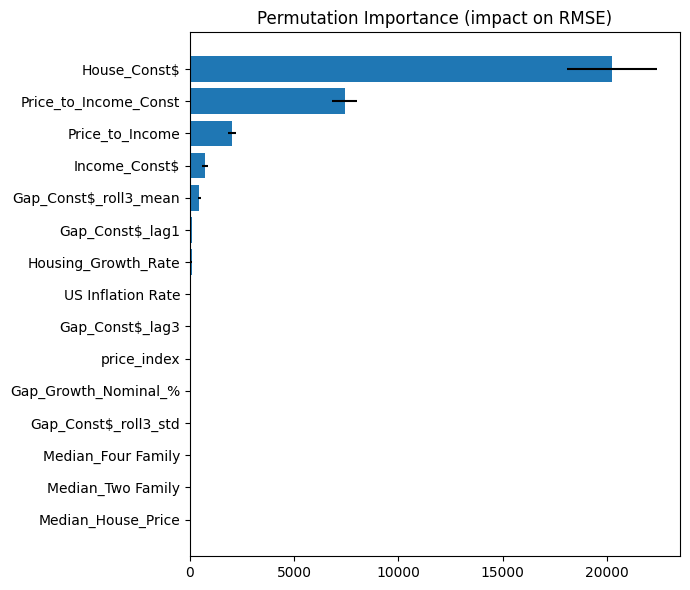

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Get feature names
if hasattr(X_train, "columns"):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"feat_{i}" for i in range(X_train.shape[1])]

perm = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1,
    scoring="neg_root_mean_squared_error"  # keeps units in RMSE
)
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False)

print("Top features by permutation importance (on test):")
display(perm_df.head(20))

# Plot top 15
top_p = perm_df.head(15).iloc[::-1]
plt.figure(figsize=(7, 6))
plt.barh(top_p["feature"], top_p["importance"], xerr=top_p["std"])
plt.title("Permutation Importance (impact on RMSE)")
plt.tight_layout()
plt.show()

The feature importance shows that Year has the strongest influence, reflecting how affordability has shifted significantly over time, while Median_Income and Month contribute moderately. This suggests that rising housing costs relative to income are largely driven by long-term trends rather than short-term factors like inflation.

### **Predicting Future Affordability Ratios**

Generates future projections from 2024-2040 for housing afforability. It extrapolates economic trends from existing data, reconstructs the engineered features, and applies the XGBoost model to forecast the afforability gap in constant dollars.

#### **Fit Future Trends**

This cell builds a base dataset **`df_future_base`** for the years of 2024-2040 and generates forward-looking trends for income, inflation, and housing prices.

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# Recover feature set used during training
X_cols = list(X_train.columns)
target_col = "Gap_Const$"

# Build base future dataframe with Year/Month
future_years = list(range(2024, 2041))

df_future_base = pd.DataFrame({
    "Year": np.repeat(future_years, 12),
    "Month": list(range(1, 13)) * len(future_years),
})

# Trend-extend median income
income_growth = features_df["Median_Income"].pct_change().mean()
last_income = features_df["Median_Income"].iloc[-1]

df_future_base["Median_Income"] = [
    last_income * (1 + income_growth) ** ((y - 2023) + (m - 1)/12)
    for (y,m) in zip(df_future_base["Year"], df_future_base["Month"])
]

# Use average inflation
avg_inflation = inflation["US Inflation Rate"].mean()
df_future_base["US Inflation Rate"] = avg_inflation

# Seasonality and future trend model for future housing prices
df_hist = features_df[["Year", "Month", "Median_House_Price"]].copy()
df_hist["t"] = np.arange(len(df_hist))

y_hp = df_hist["Median_House_Price"]
X_hp = df_hist.drop(columns=["Median_House_Price"])

hp_model = LinearRegression().fit(X_hp, y_hp)

# Build future seasonal + trend features
df_future_base["t"] = np.arange(len(features_df), len(features_df) + len(df_future_base))
df_future_season = pd.get_dummies(df_future_base, columns=["Month"], drop_first=True)

# Ensure same columns as X_hp
for c in X_hp.columns:
  if c not in df_future_season.columns:
    df_future_season[c] = 0

df_future_season = df_future_season[X_hp.columns] # same order

# Predict future house prices
df_future_base["Median_House_Price"] = hp_model.predict(df_future_season)

This cell creates a monthly timeline for future years and computes future median income in the column **`"Median_Income"`** by applying the historical average income growth rate. A long-run average inflation rate is also assigned to future periods in the column **`"US Inflation Rate"`**. Finally, it uses linear regression to fit a trend and seasonality regression on historical house prices, along with generating future house prices in the column **`"Median_House_Price"`** by applying the fitted trend and season effects.

#### **Recompute Engineered Features for Future Data**

Recalculates all of the derived economic indicators and engineered features so the future data is consistent with the historical training dataset. It mirrors the exact preprocessing pipeline used during model training.

In [ ]:
# Concatenate historical and future so lags/rolling work correctly
df_full = pd.concat([features_df[["Year", "Month", "Median_House_Price",
                                  "Median_Income", "US Inflation Rate"]],
                     #df_future_base],
                    df_future_base[["Year", "Month", "Median_House_Price", "Median_Income", "US Inflation Rate"]]],
                    ignore_index=True)

df_full = df_full.sort_values(["Year", "Month"]).reset_index(drop=True)

# Inflation factor and prince index
df_full["inflation_factor"] = 1 + df_full["US Inflation Rate"] / 100.0
df_full["price_index"] = df_full["inflation_factor"].cumprod()

# Rebase to last known historical year (2023)
last_hist_year = features_df["Year"].max()
base_idx = df_full.loc[df_full["Year"]==last_hist_year, "price_index"].iloc[-1]
df_full["rebase_factor"] = base_idx / df_full["price_index"]

# Constant-dollar metrics
df_full["House_Const$"] = df_full["Median_House_Price"] * df_full["rebase_factor"]
df_full["Income_Const$"] = df_full["Median_Income"] * df_full["rebase_factor"]

# Ratios/gaps in nominal and constant dollars
df_full["Price_to_Income"] = df_full["Median_House_Price"] / df_full["Median_Income"]
df_full["Gap_Nominal"] = df_full["Median_House_Price"] - df_full["Median_Income"]
df_full["Price_to_Income_Const"] = df_full["House_Const$"] - df_full["Income_Const$"]
df_full["Gap_Const$"] = df_full["House_Const$"] - df_full["Income_Const$"]

# Growth rates
df_full["Income_Growth_Rate"] = df_full["Median_Income"].pct_change() * 100
df_full["Housing_Growth_Rate"] = df_full["Median_House_Price"].pct_change() * 100
df_full["Gap_Growth_Nominal_%"] = df_full["Gap_Nominal"].pct_change() * 100
df_full["Gap_Growth_Const_%"] = df_full["Gap_Const$"].pct_change() * 100

# Lags
for lag in [1, 2, 3]:
  df_full[f"Gap_Const$_lag{lag}"] = df_full["Gap_Const$"].shift(lag)
  df_full[f"Price_to_Income_Const_lag{lag}"] = df_full["Price_to_Income_Const"].shift(lag)

# Rolling features
df_full["Gap_Const$_roll3_mean"] = df_full["Gap_Const$"].rolling(3, min_periods=2).mean()
df_full["Gap_Const$_roll3_std"] = df_full["Gap_Const$"].rolling(3, min_periods=2).std()

This cell combines the historical and future data to compute cumulative features correctly. The inflation adjustments are applied, building the inflation factor, creating the price index, and reabsing values to 2023 dollars.

It also recreates all nominal and real (inflation-adjusted) affordability metrics such as the Price-to-income ration and the nominal and constant-dollar affordability gaps.

Finally, it creates the lag features and rolling window statistics, such as the 3-month mean and standard deviation.

#### **Build Future Feature Matrix with Correct Columns**

This cell prepares a feature matrix for prediction that matches the exact input structure of the trained model. It does so by removing lag and rolling features for future periods since they can't be known ahead of time, selects on the columns used during model training, reorders the columns to match the training data, and finally, produces **`X_future`**, which is the model-ready future feature matrix.

In [ ]:
# Blank out lag/rolling features
lag_cols = [c for c in df_full.columns if "lag" in c]
roll_cols = [c for c in df_full.columns if "roll3" in c]

df_full.loc[df_full["Year"] >= 2024, lag_cols + roll_cols] = np.nan

# Ensure full feature alignment for prediction
df_future_full = df_full[df_full["Year"] >= 2024].copy()
X_future = df_future_full.reindex(columns=X_cols)

print("Final Future Matrix Shape:", X_future.shape)

Final Future Matrix Shape: (204, 27)


#### **Predict Future Affordability**

Uses the trained XGBoost model to produce monthly affordability forecasts.

In [ ]:
# Predict monthly future affordiability
pred_future = final_model.predict(X_future)
df_future_full["Predicted_Gap_Const$"] = pred_future

df_forecast = df_future_full[["Year", "Month", "Predicted_Gap_Const$"]].copy()

display(df_forecast.head(24))
display(df_forecast.tail(24))

,Year,Month,Predicted_Gap_Const$
207,2024,1,228408.750000
208,2024,2,226003.562500
209,2024,3,225096.406250
210,2024,4,225096.406250
211,2024,5,225096.406250
212,2024,6,225096.406250
213,2024,7,225096.406250
214,2024,8,225096.406250
215,2024,9,225096.406250
216,2024,10,225096.406250


,Year,Month,Predicted_Gap_Const$
387,2039,1,228702.078125
388,2039,2,228702.078125
389,2039,3,228702.078125
390,2039,4,228702.078125
391,2039,5,228702.078125
392,2039,6,228702.828125
393,2039,7,228702.828125
394,2039,8,228702.828125
395,2039,9,228702.828125
396,2039,10,228705.859375


This cell generates predictions for the future affordability gap. It appends the monthly predictions to **`df_forecast`**.

In [ ]:
# Calculate yearly (future) median affordability gap
df_future_yearly = (
    df_forecast
    .groupby("Year")["Predicted_Gap_Const$"]
    .median()
    .reset_index()
    .rename(columns={"Predicted_Gap_Const$": "Median_Gap_Const$"})
)

display(df_future_yearly)

,Year,Median_Gap_Const$
0,2024,225096.406250
1,2025,225361.500000
2,2026,225788.296875
3,2027,226329.078125
4,2028,226384.781250
5,2029,227011.781250
6,2030,227306.000000
7,2031,227702.968750
8,2032,227932.968750
9,2033,227948.640625


Computes the annual median afforability gap for 2024-2040 and saves those values to **`df_future_yearly`**. This will make visualizations more intepretable as the data will be displayed over years instead of months from 2024-2040.

#### **Plot Forecast 2024-2040**

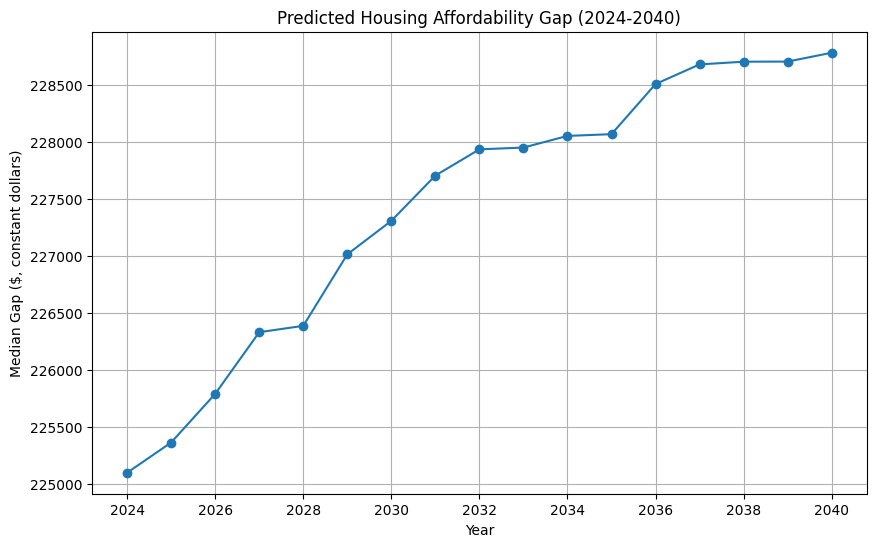

In [ ]:
import matplotlib.pyplot as plt

# Plot long-term affordability ratio
plt.figure(figsize=(10,6))
plt.plot(df_future_yearly["Year"], df_future_yearly["Median_Gap_Const$"], marker="o")
plt.title("Predicted Housing Affordability Gap (2024-2040)")
plt.xlabel("Year")
plt.ylabel("Median Gap ($, constant dollars)")
plt.grid(True)
plt.show()

This cell plots the annual median affordability gap from 2024-2040, showing the trajectory of housing affordability in constant dollars.

Overall, the plot shows that housing affordability will worsen over time, increasing from roughly `$225,000` in 2024 to over `$228,500` by 2037-2040. The curve consistently rises, with a noticeable jump around 2027-2031, but levels off slightly after 2036.

---
# **9. Summary**
---

This project examined how housing prices and occupational incomes in Connecticut have changed from 2006 to 2023 and how those changes have shaped the state’s affordability landscape. The historical data showed that home prices experienced major shifts, including the decline following the 2008 recession and a gradual rise in the years that followed, eventually accelerating sharply after 2018. In contrast, wages grew steadily but at a slower pace, and the gap between income and home values became increasingly apparent once the datasets were merged and inflation-adjusted. These early findings established the foundation for understanding the long-term affordability pressures facing residents.

The modeling phase extended these patterns into the future by forecasting monthly and yearly affordability gaps using the trained XGBoost model. The results showed a predicted median affordability gap of about 225,096 dollars in 2024, rising to approximately 228,780 dollars by 2040. The monthly projections showed only small fluctuations but a consistent upward trend, suggesting that affordability challenges are likely to persist under current conditions. This combination of historical analysis and future forecasting provided a clear picture of how affordability has shifted in the past and how it is expected to evolve moving forward.

# **10. Conclusion**

---

The completed analysis demonstrates that homeownership is becoming increasingly difficult for many Connecticut residents as the gap between income growth and rising home values continues to widen. Historical visualizations showed that income increases have not kept pace with housing prices, and the inflation-adjusted comparisons confirmed that the erosion of purchasing power is significant even when accounting for economic conditions. This growing disparity reflects broader statewide patterns in income distribution, including substantial differences between renter and homeowner households documented by CTData.org.

The forecasts reinforce these findings by projecting a gradual but steady increase in the affordability gap through 2040. The predicted median gap rises from roughly 225,000 dollars in 2024 to over 228,700 dollars by the end of the forecast window, suggesting that affordability pressures will continue even if the market remains relatively stable. The monthly predictions show little variation and no indication of improvement, highlighting the structural nature of the issue. Overall, the results point to long-term challenges for residents seeking to enter the housing market and underscore the importance of continued monitoring and analysis of the economic factors influencing affordability.

# **11. Future Work**

---

Future work could expand this analysis by applying the same methods to additional states in order to compare affordability trends across different regions of the country. Using consistent cleaning steps, inflation adjustments, and modeling approaches would allow for clear state-to-state comparisons and help identify whether Connecticut’s affordability challenges are unique or part of a broader national pattern. Incorporating data from states with contrasting housing markets, such as those with faster income growth or greater housing supply, could offer valuable context for interpreting Connecticut’s trends. Extending the predictive modeling to a multi-state framework would also make it possible to explore how different economic conditions, policies, or demographic shifts influence long-term affordability.

# **12. References**

---

Walsh, J. (2025, April 11). CT housing costs: What the ACS 5-Year estimates tell us. CTData. https://www.ctdata.org/blog/acs-5-year-estimates-released?utm_source=chatgpt.com

# **13. Youtube Link**

---

https://youtu.be/Hvup_gSS9ck